# A tour of the STARfinder spot-finding module

This notebook introduces the §2.7 spot-finding module of the maintained Python package
(`starfinder.spot_finding`, with its plan in `starfinder.dataset` and its metrics in
`starfinder.evaluation.spot_finding`). It shows how the pieces fit together and how they
are checked, by running them on synthetic scenes whose spot positions are known exactly:

1. the architecture and conventions: stages, methods and configs, the method registry, the
   detection plan and the execution device;
2. scenes with known truth;
3. the four pipeline methods, one by one, through `find_spots`;
4. local maxima in detail: threshold modes, the noise record, the within-channel merge and
   border exclusion;
5. the Starfish LoG: parity with starfish, intensity scaling, threshold units and memory;
6. pretrained weights: the cache, verification and the errors;
7. detection in several rounds and the `candidates` checkpoint;
8. one field of view (FOV) through `FOV.run`, with its run record and the workflow key;
9. how the module is checked, and its known limits.

Every section explains a design choice first and then runs the code that shows it. The
design itself is documented in `docs/`; this notebook links those pages rather than
repeating them. The notebook explains and demonstrates the design. **It is not a
benchmark:** each method runs once, at its native defaults (the Starfish LoG, which has
none, with the starfish tutorial values), on one synthetic scene and one seed, so the error
tables below describe this demonstration only. They do not rank the methods or recommend a
method, a model or a default.

**Scope and resources.** The scenes are generated in memory and never exceed the `small`
benchmark preset. The notebook needs no downloaded data, MATLAB, GPU or network access, but
it does need the optional `spotiflow` and `piscis` extras and the known pretrained weights,
already fetched into the cache that `STARFINDER_WEIGHTS_DIR` names (the notebook never
fetches; section 6 shows how the cache is checked). Every random draw comes from a fixed
seed and the numerical libraries run on one thread, so a second execution prints the same
numbers on the same host and library build, except the wall-clock timings that section 9
collects. Files are written only under a temporary directory that the notebook creates and
removes in its last cell.

To execute it from `src/python` in a locked environment that includes the `dev` group
(which provides Jupyter) and the two extras, with one numerical thread and no GPU:

```bash
export OMP_NUM_THREADS=1 MKL_NUM_THREADS=1 OPENBLAS_NUM_THREADS=1 CUDA_VISIBLE_DEVICES=""
export STARFINDER_WEIGHTS_DIR=<the weights cache>
uv run jupyter nbconvert --to notebook --execute --output-dir <new directory> \
    ../../example/introduction/starfinder_spot_finding_tour.ipynb
```

The setup cell draws figures inline, keeps numerical libraries on one thread (set before
NumPy is imported) and hides any GPU. It checks that `starfinder` is imported from the
checkout that holds this notebook, and that importing the spot-finding module does not
import the optional backends: torch, Spotiflow and Piscis are imported only when a learned
method runs. The cell then imports torch and sets its thread count to one, as the
validation does, so every learned detection below is single-threaded and repeatable. The
helper `clean` writes the weights cache as `$STARFINDER_WEIGHTS_DIR` and the temporary
workspace as `<workspace>`, so no machine-specific path appears in the output; `error_of`
prints the error a call raises; and `timed` records the wall time of the slow steps for
section 9.

In [1]:
%matplotlib inline
import os

for variable in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS",
                 "NUMBA_NUM_THREADS"):
    os.environ.setdefault(variable, "1")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "")

import sys
import json
import tempfile
import time
import warnings
from contextlib import contextmanager
from dataclasses import MISSING, fields, replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import starfinder
import starfinder.dataset
import starfinder.evaluation.spot_finding
import starfinder.spot_finding
import starfinder.synthetic

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 80)

REPOSITORY = Path(starfinder.__file__).resolve().parents[3]
print("starfinder imported from:", Path(starfinder.__file__).resolve().relative_to(REPOSITORY).as_posix())
print("the same checkout as this notebook:", Path.cwd().resolve().is_relative_to(REPOSITORY))
print("backends imported by the spot-finding module:",
      {name: name in sys.modules for name in ("torch", "spotiflow", "piscis")})

import torch

torch.set_num_threads(1)
print("torch:", torch.__version__, " CUDA build:", torch.version.cuda, " threads:", torch.get_num_threads(),
      " CUDA_VISIBLE_DEVICES:", repr(os.environ["CUDA_VISIBLE_DEVICES"]))

assert os.environ.get("STARFINDER_WEIGHTS_DIR"), "set STARFINDER_WEIGHTS_DIR to the weights cache"
WEIGHTS = Path(os.environ["STARFINDER_WEIGHTS_DIR"]).expanduser().resolve()
_workspace = tempfile.TemporaryDirectory(prefix="starfinder-spot-finding-tour-")
WORKSPACE = Path(_workspace.name)
TIMINGS = {}


def clean(text):
    # Write the weights cache as $STARFINDER_WEIGHTS_DIR and the temporary workspace as <workspace>.
    return str(text).replace(str(WEIGHTS), "$STARFINDER_WEIGHTS_DIR").replace(str(WORKSPACE), "<workspace>")


def show(obj):
    print(clean(obj if isinstance(obj, str) else repr(obj)))


def error_of(call):
    # Run call, which must raise; return "<error type>: <message>" with clean paths.
    try:
        call()
    except Exception as error:
        return clean(f"{type(error).__name__}: {error}")
    raise AssertionError("expected an error")


@contextmanager
def timed(label):
    start = time.perf_counter()
    yield
    TIMINGS[label] = time.perf_counter() - start


print("weights cache: $STARFINDER_WEIGHTS_DIR;", "workspace: a new temporary directory, removed at the end")

starfinder imported from: src/python/starfinder/__init__.py
the same checkout as this notebook: True
backends imported by the spot-finding module: {'torch': False, 'spotiflow': False, 'piscis': False}


torch: 2.7.1+cpu  CUDA build: None  threads: 1  CUDA_VISIBLE_DEVICES: ''
weights cache: $STARFINDER_WEIGHTS_DIR; workspace: a new temporary directory, removed at the end


## 1. Architecture and conventions

**Terms.** The spot-finding design uses a few words with fixed meanings
([docs/method-registry.md](../../docs/method-registry.md),
[docs/spot-finding-contract.md](../../docs/spot-finding-contract.md)):

* a **stage** is a pipeline stage: preprocessing, registration, spot finding, extraction
  and decoding;
* a **method** is a registrable algorithm of a stage, such as `starfish_log`;
* a **config** is the frozen dataclass of one method, validated at construction. Its
  *exact* type selects the method, and its `method` field (not an init argument) equals the
  method's registered name;
* a **plan** (`SpotFindingPlan`) is one config for every channel, with whole-config
  overrides for named channels and, optionally, the rounds to detect in.

**The registry.** `SPOT_FINDING_METHODS` is a plain dictionary from each exact config
type to a frozen `SpotFindingSpec` that declares the method's name and capabilities.
Everything that needs the set of methods (`find_spots`, `SpotFindingResult`,
`SpotFindingPlan`, `PipelineConfig.detection`, `FOV.find_spots`, the workflow adapter and
the checkpoint reader) derives it from the registry, so there is no second list to keep
in step. For spot finding the spec declares:

* `pipeline`: whether `FOV.find_spots` and `PipelineConfig.detection` accept the method
  (the registration-landmark detectors are registered but are not pipeline methods);
* `dimensions`: `2` when a Z=1 input is detected as a YX plane (with z=0), `3` when Z>1
  is detected in 3D;
* `min_shape_zyx`: the smallest accepted size of each axis (a Z=1 input is checked against
  its last two entries);
* `output_columns`: the spot-table columns besides `spot_id`, where a trailing `?` marks an
  optional column that a Boolean config field adds;
* `requires`: optional dependencies with the extra that installs them, imported only when
  the method runs;
* `weights`: whether the config names pretrained weights from the known-weights table.

The next cell prints the registry as a table, with the installed version of each optional
dependency.

In [2]:
from importlib import metadata

from starfinder.spot_finding import SPOT_FINDING_METHODS


def installed(distribution):
    try:
        return metadata.version(distribution)
    except metadata.PackageNotFoundError:
        return "not installed"


registry = pd.DataFrame([dict(
    name=spec.name,
    config=config_type.__name__,
    pipeline=spec.pipeline,
    dimensions=", ".join(f"{d}D" for d in sorted(spec.dimensions)),
    min_shape_zyx=spec.min_shape_zyx,
    output_columns=", ".join(spec.output_columns),
    required_extra=", ".join(f"{d.distribution} [{d.extra}] {installed(d.distribution)}" for d in spec.requires) or "none",
    weights=spec.weights,
) for config_type, spec in SPOT_FINDING_METHODS.items()])
registry

,name,config,pipeline,dimensions,min_shape_zyx,output_columns,required_extra,weights
0,local_maxima,LocalMaximaConfig,True,"2D, 3D","(1, 1, 1)","z, y, x, channel, peak_intensity?",none,False
1,noise_landmark,NoiseLandmarkConfig,False,"2D, 3D","(1, 1, 1)","z, y, x",none,False
2,percentile_centroid,PercentileCentroidConfig,False,"2D, 3D","(1, 1, 1)","z, y, x",none,False
3,starfish_log,StarfishLogConfig,True,"2D, 3D","(1, 1, 1)","z, y, x, channel, peak_intensity, radius",none,False
4,spotiflow,SpotiflowConfig,True,"2D, 3D","(7, 6, 6)","z, y, x, channel, peak_intensity, probability","spotiflow [spotiflow] 0.6.5, torch [spotiflow] 2.7.1+cpu",True
5,piscis,PiscisConfig,True,"2D, 3D","(2, 1, 1)","z, y, x, channel, peak_intensity","piscis [piscis] 1.1.0, torch [piscis] 2.7.1+cpu",True


**The detection plan.** `PipelineConfig.detection` accepts a registered pipeline config or
a `SpotFindingPlan`; a bare config means `SpotFindingPlan(config)`. A `ChannelOverride`
replaces the *whole* config of one channel, named by its label. Its config must have the
plan's exact type (one method per run), and it may change any setting except one that
changes the output columns. Every channel's effective config, overridden or not, is
recorded in `diagnostics["effective_settings"]`. The cell builds a plan with one override
and shows the rules it enforces.

**The device.** The device belongs to execution, not to a method: `find_spots(...,
device=...)` and `ExecutionConfig(device=...)` share one check, so a later stage can reuse
it unchanged. §2.7 runs on CPU only, so `"cpu"` is the only accepted value, and each
detection records an execution entry (device, framework, threads), shown in section 3.

In [3]:
from starfinder.dataset import ExecutionConfig, PipelineConfig
from starfinder.spot_finding import ChannelOverride, LocalMaximaConfig, SpotFindingPlan, StarfishLogConfig

CHANNELS = ("ch00", "ch01", "ch02", "ch03")
plan = SpotFindingPlan(LocalMaximaConfig(channel_labels=CHANNELS),
                       (ChannelOverride("ch03", LocalMaximaConfig(threshold_value=6.0)),))
show(plan)
print("accepted by PipelineConfig:", PipelineConfig(detection=plan).detection == plan)
other_method = StarfishLogConfig(min_sigma=1, max_sigma=2, num_sigma=3, threshold=0.1)
print("\nrules:")
print(" ", error_of(lambda: SpotFindingPlan(LocalMaximaConfig(), (ChannelOverride("ch03", other_method),))))
print(" ", error_of(lambda: SpotFindingPlan(LocalMaximaConfig(), (
    ChannelOverride("ch03", LocalMaximaConfig(measure_peak_intensity=False)),))))
print(" ", error_of(lambda: SpotFindingPlan(LocalMaximaConfig(channel_labels=CHANNELS),
                                            (ChannelOverride("ch09", LocalMaximaConfig()),))))
print("\ndevice:", ExecutionConfig().device)
print(" ", error_of(lambda: ExecutionConfig(device="cuda")))

SpotFindingPlan(config=LocalMaximaConfig(threshold_mode='noise', threshold_value=5.0, min_distance_voxels=1, exclude_border=True, channel_labels=('ch00', 'ch01', 'ch02', 'ch03'), measure_peak_intensity=True, merge_radius_zyx=None, method='local_maxima'), channel_overrides=(ChannelOverride(channel='ch03', config=LocalMaximaConfig(threshold_mode='noise', threshold_value=6.0, min_distance_voxels=1, exclude_border=True, channel_labels=None, measure_peak_intensity=True, merge_radius_zyx=None, method='local_maxima')),), rounds=None)
accepted by PipelineConfig: True

rules:
  TypeError: the override of channel 'ch03' is a StarfishLogConfig, not the plan's LocalMaximaConfig
  ValueError: the override of channel 'ch03' sets measure_peak_intensity=False, unlike the plan's config, which would change the output column 'peak_intensity'; an override may change any setting except one that changes the output columns
  ValueError: channel 'ch09' is not one of the channel labels ['ch00', 'ch01', 'ch02',

**Where the accepted pages live.** The design is specified in three accepted pages, whose
titles the cell prints from the files: the behavior before §2.7, with the golden test, is
in [docs/spot-finding-baseline.md](../../docs/spot-finding-baseline.md); the registry
entries, configs, plan, workflow keys, device, weights, rounds, checkpoint and diagnostics
are in [docs/spot-finding-contract.md](../../docs/spot-finding-contract.md); and the
numerical rules of each method and the engineering validation design (checks S1 to S16)
are in [docs/spot-finding-algorithms.md](../../docs/spot-finding-algorithms.md). The
registry rules shared by all stages are in
[docs/method-registry.md](../../docs/method-registry.md).

In [4]:
for page in ("spot-finding-baseline", "spot-finding-contract", "spot-finding-algorithms", "method-registry"):
    path = REPOSITORY / "docs" / f"{page}.md"
    print(f"docs/{page}.md: {path.read_text().splitlines()[0].lstrip('# ')}")

docs/spot-finding-baseline.md: Spot-finding baseline
docs/spot-finding-contract.md: Spot-finding contract
docs/spot-finding-algorithms.md: Spot-finding algorithm specification
docs/method-registry.md: Method registry across stages


## 2. Scenes with known truth

The validation's isolated-spot scenes are built from known positions with the §2.12
image-formation model ([docs/synthetic-specification.md](../../docs/synthetic-specification.md)):
`generate_formed_scene` renders each listed position as a Gaussian with the given
brightness and widths on a constant baseline, adds Poisson and read noise and writes
uint16. The truth is the rendered centres.

The 3D scene puts one spot in each column of a regular YX grid (`GRID_YX`), on alternating
Z layers (`LAYERS_Z`), and jitters every axis by up to `JITTER` voxels from the seed; the
Z=1 counterpart puts the same YX grid on one plane. The cell builds both as the validation
helpers do (the same positions, appearance and seed), under the notebook's own scene key,
so the noise realization differs from the test's. It prints the shapes, the appearance,
the density and the smallest distance between two truth spots. The four-channel codebook
only names the channel the spots are rendered in; the scenes keep that one channel.

In [5]:
from starfinder.barcode import Codebook
from starfinder.synthetic import BackgroundConfig, FormedSceneConfig, NoiseConfig, ScalarDistribution, generate_formed_scene

SEED = 100
SHAPES = {"3D": (32, 64, 64), "Z=1": (1, 64, 64)}
BRIGHTNESS, SIGMA_Z, SIGMA_YX, BASELINE, READ_NOISE = 1500.0, 1.5, 1.3, 100.0, 3.0
GRID_YX = np.arange(5, 60, 6, dtype=float)
LAYERS_Z = (8.0, 16.0, 24.0)
JITTER = 0.5


def isolated_positions(case, seed):
    # One spot per column of the YX grid, Z layers alternating (Z=1: z=0), every axis jittered in [-JITTER, JITTER).
    rng = np.random.default_rng([266, seed, {"3D": 0, "Z=1": 1}[case]])
    layers = LAYERS_Z if case == "3D" else (0.0, 0.0, 0.0)
    grid = np.array([(layers[(i + j) % 3], y, x) for i, y in enumerate(GRID_YX) for j, x in enumerate(GRID_YX)])
    jitter = rng.uniform(-JITTER, JITTER, size=grid.shape)
    if case == "Z=1":
        jitter[:, 0] = 0.0
    return grid + jitter


def isolated_scene(case, seed=SEED):
    # (uint16 ZYX image, truth (N, 3) ZYX) of the isolated-spot scene.
    book = Codebook(pd.DataFrame(dict(gene_id=["spot"], color_sequence=["1"])), ("round1",), CHANNELS)
    config = FormedSceneConfig(
        dataset_version="tour-isolated", sample_id="tour", scene_key=f"tour/isolated/{case}", seed=seed,
        shape_zyx=SHAPES[case], dtype="uint16", coordinates=tuple(map(tuple, isolated_positions(case, seed))),
        brightness=ScalarDistribution(parameters=(BRIGHTNESS,)),
        axial_width=ScalarDistribution(parameters=(SIGMA_Z,)), lateral_width=ScalarDistribution(parameters=(SIGMA_YX,)),
        background=BackgroundConfig(baseline_enabled=True, baseline=((BASELINE,) * len(CHANNELS),)),
        noise=NoiseConfig(dependent_enabled=True, alpha=1.0, model="poisson", independent_enabled=True, sigma=READ_NOISE))
    scene = generate_formed_scene(book, config=config)
    return scene.rounds["round1"][..., 0], scene.round_truth[["z", "y", "x"]].to_numpy(float)


images, truths = {}, {}
for case in SHAPES:
    images[case], truths[case] = isolated_scene(case)
print("GRID_YX:", GRID_YX, " LAYERS_Z:", LAYERS_Z, " JITTER:", JITTER, " seed:", SEED)
print(f"appearance: brightness {BRIGHTNESS}, sigma Z {SIGMA_Z} and YX {SIGMA_YX} voxels, baseline {BASELINE}, "
      f"Poisson plus read noise {READ_NOISE}")
for case in SHAPES:
    image, truth = images[case], truths[case]
    gaps = np.linalg.norm(truth[:, None] - truth[None], axis=-1)[~np.eye(len(truth), dtype=bool)]
    print(f"{case:>4}: image {image.shape} {image.dtype}, values {image.min()} to {image.max()}; {len(truth)} truth spots, "
          f"density {len(truth) / image.size:.2g} per voxel, smallest separation {gaps.min():.2f} voxels")

GRID_YX: [ 5. 11. 17. 23. 29. 35. 41. 47. 53. 59.]  LAYERS_Z: (8.0, 16.0, 24.0)  JITTER: 0.5  seed: 100
appearance: brightness 1500.0, sigma Z 1.5 and YX 1.3 voxels, baseline 100.0, Poisson plus read noise 3.0
  3D: image (32, 64, 64) uint16, values 61 to 1651; 100 truth spots, density 0.00076 per voxel, smallest separation 7.67 voxels
 Z=1: image (1, 64, 64) uint16, values 72 to 1649; 100 truth spots, density 0.024 per voxel, smallest separation 5.15 voxels


The figure shows the maximum projection over Z of the 3D scene and the Z=1 plane, with the
truth positions marked.

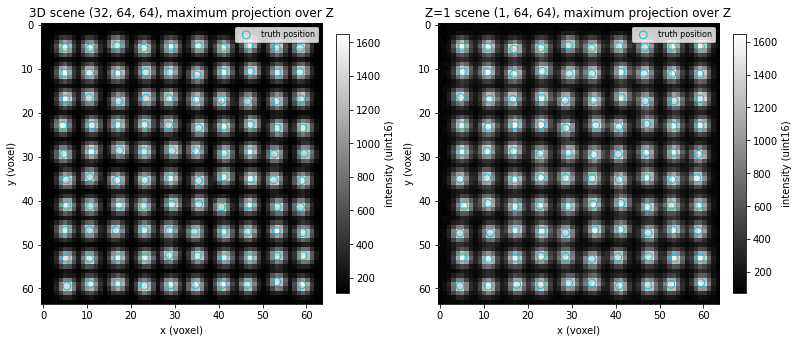

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), dpi=72, constrained_layout=True)
for axis, case in zip(axes, SHAPES):
    shown = axis.imshow(images[case].max(axis=0), cmap="gray")
    axis.scatter(truths[case][:, 2], truths[case][:, 1], s=60, facecolors="none", edgecolors="tab:cyan",
                 linewidths=1.0, label="truth position")
    axis.set(title=f"{case} scene {images[case].shape}, maximum projection over Z", xlabel="x (voxel)",
             ylabel="y (voxel)")
    axis.legend(loc="upper right", fontsize=8, framealpha=0.8)
    fig.colorbar(shown, ax=axis, label="intensity (uint16)", shrink=0.8)
plt.show()

## 3. The four methods one by one through `find_spots`

`find_spots(image, *, config, metadata, spot_namespace, device="cpu")` takes a finite ZYX
or ZYXC image and one registered config or a plan. Before the method runs, it looks up the
exact config type in `SPOT_FINDING_METHODS`, checks the device, the declared dimensions and
the minimum shape, and imports the method's optional dependencies. It returns a
`SpotFindingResult`: the typed spot table (`spot_id` and `z, y, x` in zero-based voxel
indices, then the method's declared columns), the metadata, the identity namespace, the
config and plan, and a diagnostics dictionary. Every method fills the same keys:
per-channel `thresholds`, `counts` and `outcomes`; `effective_settings`, with the native
defaults that `None` resolved; `measurements` (what each measured column means);
`software`; and `execution`. Methods add their own keys: the local-maxima noise record, the
summary `native` of a native score or size column, the `geometry` of the tiling or the
memory, and the `model` record of a learned method.

Each result is compared with the truth by `evaluate_spots` (recall and precision under the
validation's matching policy, `MATCH` below) and by `localization_errors` (over the matched
pairs: the per-axis absolute errors and the lateral and 3D distances, as maxima and 95th
percentiles, and the number of matches whose Z error is above one voxel). The helper
`detect` runs one case, keeps its result and its row of the results table, and records its
wall time for section 9; `defaults` lists a config type's init fields with their defaults.

In [7]:
from starfinder.evaluation.spot_finding import evaluate_spots, localization_errors
from starfinder.image import ImageMetadata
from starfinder.spot_finding import find_spots

METADATA = ImageMetadata("tour")
NAMESPACE = "tour/isolated"
MATCH = dict(policy="greedy", threshold=3.0, boundary="inclusive", units="voxel")
print("MATCH:", MATCH)
RESULTS, ROWS, STATISTICS = {}, [], [None]


def evaluate(spots, truth):
    detected = spots[["z", "y", "x"]].to_numpy()
    matched = evaluate_spots(detected, truth, reference_metadata=METADATA, observed_metadata=METADATA, **MATCH)
    return matched, localization_errors(matched, detected, truth)


def detect(label, case, config):
    # Run one method on one scene; keep the result and its row of the results table.
    with timed(f"find_spots {label}, {case} {SHAPES[case]}"):
        result = find_spots(images[case], config=config, metadata=METADATA, spot_namespace=NAMESPACE)
    matched, errors = evaluate(result.spots, truths[case])
    RESULTS[label, case] = result
    STATISTICS[0] = errors.config["statistics"]
    row = dict(method=label, scene=case, detections=len(result.spots), recall=matched.values["recall"],
               precision=matched.values["precision"],
               **{k: errors.values[k] for k in ("dist_max", "dist_p95", "lateral_max", "abs_z_max")},
               abs_z_gt_1=errors.counts["n_abs_z_gt_1"])
    ROWS.append(row)
    return result, pd.DataFrame([row]).round(3)


def defaults(config_type):
    # The init fields of a config type with their defaults ("required" when there is none).
    return {f.name: "required" if f.default is MISSING else f.default for f in fields(config_type) if f.init}

MATCH: {'policy': 'greedy', 'threshold': 3.0, 'boundary': 'inclusive', 'units': 'voxel'}


### Local maxima

`local_maxima` is the existing Starfinder detector, unchanged by §2.7 except for one opt-in
field (section 4): per channel, `skimage.feature.peak_local_max` finds the regional maxima
above a threshold, at least `min_distance_voxels` apart, with optional border exclusion.
Its default threshold mode `noise` sets the threshold at the channel's median plus
`threshold_value` robust standard deviations (the MAD scaled to a Gaussian σ); section 4
shows the other modes. The output columns are `z, y, x` (integer voxel positions as
float64), `channel` and the optional `peak_intensity` (the original pixel value). The cell
prints the native defaults, runs it on both scenes and prints the noise record, the
threshold and the evaluation.

In [8]:
LM = LocalMaximaConfig()
print("LocalMaximaConfig defaults:", defaults(LocalMaximaConfig))
for case in SHAPES:
    result, row = detect("local_maxima", case, LM)
    print(f"\n{case}: {result}")
    print("  columns:", list(result.spots.columns), " dtypes:", dict(result.spots.dtypes.astype(str)))
    print("  effective settings:", result.diagnostics["effective_settings"]["0"])
    print("  noise record:", result.diagnostics["noise"]["0"], " outcomes:", result.diagnostics["outcomes"])
    print(f"  image maximum {images[case].max()} against the threshold {result.diagnostics['thresholds'][0]:.1f}")
    print(row.to_string(index=False))

LocalMaximaConfig defaults: {'threshold_mode': 'noise', 'threshold_value': 5.0, 'min_distance_voxels': 1, 'exclude_border': True, 'channel_labels': None, 'measure_peak_intensity': True, 'merge_radius_zyx': None}

3D: SpotFindingResult: 100 spots × [spot_id, z, y, x, ...]
  columns: ['spot_id', 'z', 'y', 'x', 'channel', 'peak_intensity']  dtypes: {'spot_id': 'string', 'z': 'float64', 'y': 'float64', 'x': 'float64', 'channel': 'int64', 'peak_intensity': 'float64'}
  effective settings: {'threshold_mode': 'noise', 'threshold_value': 5.0, 'min_distance_voxels': 1, 'exclude_border': True, 'channel_labels': None, 'measure_peak_intensity': True, 'merge_radius_zyx': None, 'method': 'local_maxima'}
  noise record: {'zero_fraction': 0.0, 'median': 105.0, 'mad': 10.0, 'threshold': 179.13}  outcomes: {'0': 'ok'}
  image maximum 1651 against the threshold 179.1
      method scene  detections  recall  precision  dist_max  dist_p95  lateral_max  abs_z_max  abs_z_gt_1
local_maxima    3D         100   

On the 3D scene every spot is found. On the Z=1 plane the result is empty: the spots cover
so much of the plane that the channel's median and MAD measure the spots rather than the
noise, and the threshold rises above every peak, as the printed noise record and image
maximum show. This high-density behavior of the noise threshold is known and flagged, not
changed (section 9); the noise record makes it visible.

### Starfish LoG

`starfish_log` is a native reimplementation of starfish's `BlobDetector` (volume mode, no
reference image, one channel at a time): scikit-image `blob_log` on the image scaled to
[0, 1], followed by starfish's post-processing (a single plane is squeezed to 2D with z=0,
coordinates are truncated to integers, and `radius` is `round(σ·√ndim)`). Starfish has no
defaults for its sigma range, number of scales and threshold, so these four fields are
required; the notebook uses the starfish ISS tutorial values `LOG` that the validation
uses, which are an example, not a default. The output adds `radius`; the diagnostics add
the `native` radius summary, the `geometry` memory estimate and the `measurements`.

In [9]:
LOG = StarfishLogConfig(min_sigma=1, max_sigma=10, num_sigma=30, threshold=0.01)
print("StarfishLogConfig defaults:", defaults(StarfishLogConfig))
print("LOG:", LOG)
for case in SHAPES:
    result, row = detect("starfish_log", case, LOG)
    print(f"\n{case}: {result}")
    print("  columns:", list(result.spots.columns))
    print("  effective settings:", result.diagnostics["effective_settings"]["0"])
    print("  native:", result.diagnostics["native"]["0"])
    print("  geometry:", result.diagnostics["geometry"])
    print(row.to_string(index=False))
print("\nmeasurements:", result.diagnostics["measurements"])

StarfishLogConfig defaults: {'min_sigma': 'required', 'max_sigma': 'required', 'num_sigma': 'required', 'threshold': 'required', 'overlap': 0.5, 'exclude_border': False, 'channel_labels': None}
LOG: StarfishLogConfig(min_sigma=1, max_sigma=10, num_sigma=30, threshold=0.01, overlap=0.5, exclude_border=False, channel_labels=None, method='starfish_log')



3D: SpotFindingResult: 100 spots × [spot_id, z, y, x, ...]
  columns: ['spot_id', 'z', 'y', 'x', 'channel', 'peak_intensity', 'radius']
  effective settings: {'min_sigma': 1, 'max_sigma': 10, 'num_sigma': 30, 'threshold': 0.01, 'overlap': 0.5, 'exclude_border': False, 'channel_labels': None, 'method': 'starfish_log'}
  native: {'radius': {'min': 2.0, 'median': 2.0, 'max': 2.0}}
  geometry: {'voxels': 131072, 'num_sigma': 30, 'bytes_per_voxel_and_sigma': 10.4, 'scale_space_bytes_estimate': 40894464.0}
      method scene  detections  recall  precision  dist_max  dist_p95  lateral_max  abs_z_max  abs_z_gt_1
starfish_log    3D         100     1.0        1.0     0.723     0.667        0.658      0.537           0

Z=1: SpotFindingResult: 43 spots × [spot_id, z, y, x, ...]
  columns: ['spot_id', 'z', 'y', 'x', 'channel', 'peak_intensity', 'radius']
  effective settings: {'min_sigma': 1, 'max_sigma': 10, 'num_sigma': 30, 'threshold': 0.01, 'overlap': 0.5, 'exclude_border': False, 'channel_la

### Spotiflow

`spotiflow` runs Spotiflow with named pretrained weights, one channel at a time: the
network predicts a probability heatmap and a flow field, peaks of the heatmap above
`prob_thresh` become spots, and the flow refines them to sub-pixel positions. There is no
default model: every config names a row of the known-weights table (section 6). A 3D model
detects a Z>1 image in 3D, and a 2D model detects a Z=1 image as a YX plane; any other
pairing raises (below). `prob_thresh=None` means the threshold stored with the weights,
and `subpix` and `n_tiles` default to Spotiflow's own choices; the resolved values are
recorded in `effective_settings`. The output adds `probability`, the spot-wise heatmap
value. The notebook uses `smfish_3d` on the 3D scene and `general` on the Z=1 plane, for
demonstration only.

The model record lists the verified weights files (path, SHA-256, source and revision) and
the training pixel size; the cell prints the paths relative to the cache.

In [10]:
from starfinder.spot_finding import SpotiflowConfig

SPOTIFLOW = {"3D": SpotiflowConfig("smfish_3d"), "Z=1": SpotiflowConfig("general")}
print("SpotiflowConfig defaults:", defaults(SpotiflowConfig))


def model_summary(record):
    return {"method": record["method"], "model": record["model"],
            "files": [clean(a["path"]) for a in record["artifacts"]],
            "training_pixel_size": record["training_pixel_size"]}


for case, config in SPOTIFLOW.items():
    result, row = detect(f"spotiflow {config.model}", case, config)
    print(f"\n{case}: {result}")
    print("  columns:", list(result.spots.columns))
    print("  effective settings:", result.diagnostics["effective_settings"]["0"])
    print("  native:", result.diagnostics["native"]["0"], " geometry:", result.diagnostics["geometry"])
    print("  model:", model_summary(result.diagnostics["model"]))
    print(row.to_string(index=False))
print("\nexecution:", result.diagnostics["execution"])

SpotiflowConfig defaults: {'model': 'required', 'prob_thresh': None, 'min_distance': 1, 'exclude_border': False, 'subpix': None, 'n_tiles': None, 'scale': 1.0, 'channel_labels': None}



3D: SpotFindingResult: 100 spots × [spot_id, z, y, x, ...]
  columns: ['spot_id', 'z', 'y', 'x', 'channel', 'peak_intensity', 'probability']
  effective settings: {'model': 'smfish_3d', 'prob_thresh': 0.4, 'min_distance': 1, 'exclude_border': False, 'subpix': True, 'n_tiles': (1, 1, 1), 'scale': 1.0, 'channel_labels': None, 'method': 'spotiflow'}
  native: {'probability': {'min': 0.5708596110343933, 'median': 0.8435330092906952, 'max': 0.9210004806518555}}  geometry: {'n_tiles': (1, 1, 1)}
  model: {'method': 'spotiflow', 'model': 'smfish_3d', 'files': ['$STARFINDER_WEIGHTS_DIR/spotiflow/smfish_3d/best.pt', '$STARFINDER_WEIGHTS_DIR/spotiflow/smfish_3d/config.yaml', '$STARFINDER_WEIGHTS_DIR/spotiflow/smfish_3d/last.pt', '$STARFINDER_WEIGHTS_DIR/spotiflow/smfish_3d/thresholds.yaml', '$STARFINDER_WEIGHTS_DIR/spotiflow/smfish_3d/train_config.yaml'], 'training_pixel_size': '0.13 um YX, 0.48 um Z'}
             method scene  detections  recall  precision  dist_max  dist_p95  lateral_max  ab


Z=1: SpotFindingResult: 100 spots × [spot_id, z, y, x, ...]
  columns: ['spot_id', 'z', 'y', 'x', 'channel', 'peak_intensity', 'probability']
  effective settings: {'model': 'general', 'prob_thresh': 0.49999999999999994, 'min_distance': 1, 'exclude_border': False, 'subpix': True, 'n_tiles': (1, 1), 'scale': 1.0, 'channel_labels': None, 'method': 'spotiflow'}
  native: {'probability': {'min': 0.7890791893005371, 'median': 0.8651772737503052, 'max': 0.957963764667511}}  geometry: {'n_tiles': (1, 1)}
  model: {'method': 'spotiflow', 'model': 'general', 'files': ['$STARFINDER_WEIGHTS_DIR/spotiflow/general/best.pt', '$STARFINDER_WEIGHTS_DIR/spotiflow/general/config.yaml', '$STARFINDER_WEIGHTS_DIR/spotiflow/general/last.pt', '$STARFINDER_WEIGHTS_DIR/spotiflow/general/thresholds.yaml', '$STARFINDER_WEIGHTS_DIR/spotiflow/general/train_config.yaml'], 'training_pixel_size': '0.04, 0.1, 0.11, 0.15, 0.32 and 0.34 um (mixed training data)'}
           method scene  detections  recall  precision  d

### Piscis

`piscis` runs Piscis (the `Piscis` class) with named pretrained weights, one channel at a
time. Each plane is standardized and tiled, the network predicts a label map and a
sub-pixel displacement field, and spots are where the max-pooled labels exceed
`threshold`. A Z=1 image runs in **plane mode** (peaks at least `min_distance` pixels
apart, z=0); a Z>1 image runs in **stack mode**, where spots are connected components of
the thresholded labels across planes, so z is an integer and spots aligned vertically
merge. The same model file serves both modes; there is no default model, and the notebook
uses `20251212` for demonstration only. `input_size=None` means the model's tile side,
recorded in `effective_settings`; the tiling (tile size, overlap and the keep-boundaries
where tiles are cut) is recorded in `geometry`. Piscis returns coordinates only, so the
table has no score column.

In [11]:
from starfinder.spot_finding import PiscisConfig

PISCIS = PiscisConfig("20251212")
print("PiscisConfig defaults:", defaults(PiscisConfig))
for case in SHAPES:
    result, row = detect(f"piscis {PISCIS.model}", case, PISCIS)
    spots = result.spots
    print(f"\n{case}: {result}")
    print("  columns:", list(spots.columns))
    print("  effective settings:", result.diagnostics["effective_settings"]["0"])
    print("  geometry:", result.diagnostics["geometry"])
    print("  model:", model_summary(result.diagnostics["model"]))
    print("  every z is an integer:", bool((spots.z == np.round(spots.z)).all()),
          " every z is 0:", bool((spots.z == 0).all()))
    print(row.to_string(index=False))

PiscisConfig defaults: {'model': 'required', 'threshold': 0.5, 'min_distance': 1, 'input_size': None, 'scale': 1.0, 'channel_labels': None}



3D: SpotFindingResult: 100 spots × [spot_id, z, y, x, ...]
  columns: ['spot_id', 'z', 'y', 'x', 'channel', 'peak_intensity']
  effective settings: {'model': '20251212', 'threshold': 0.5, 'min_distance': 1, 'input_size': 256, 'scale': 1.0, 'channel_labels': None, 'method': 'piscis'}
  geometry: {'mode': 'stack', 'tile_size': [256, 256], 'overlap': [0, 0], 'keep_boundaries': {'y': [], 'x': []}}
  model: {'method': 'piscis', 'model': '20251212', 'files': ['$STARFINDER_WEIGHTS_DIR/piscis/20251212/20251212.pt'], 'training_pixel_size': 'not published by the authors'}
  every z is an integer: True  every z is 0: False
         method scene  detections  recall  precision  dist_max  dist_p95  lateral_max  abs_z_max  abs_z_gt_1
piscis 20251212    3D         100     1.0        1.0      1.75     1.156        0.094       1.75           9



Z=1: SpotFindingResult: 100 spots × [spot_id, z, y, x, ...]
  columns: ['spot_id', 'z', 'y', 'x', 'channel', 'peak_intensity']
  effective settings: {'model': '20251212', 'threshold': 0.5, 'min_distance': 1, 'input_size': 256, 'scale': 1.0, 'channel_labels': None, 'method': 'piscis'}
  geometry: {'mode': 'plane', 'tile_size': [256, 256], 'overlap': [0, 0], 'keep_boundaries': {'y': [], 'x': []}}
  model: {'method': 'piscis', 'model': '20251212', 'files': ['$STARFINDER_WEIGHTS_DIR/piscis/20251212/20251212.pt'], 'training_pixel_size': 'not published by the authors'}
  every z is an integer: True  every z is 0: True
         method scene  detections  recall  precision  dist_max  dist_p95  lateral_max  abs_z_max  abs_z_gt_1
piscis 20251212   Z=1         100     1.0        1.0     0.112      0.07        0.112        0.0           0


**Results.** The table collects the rows above. The error columns are in voxels: `dist` is
the 3D distance and `lateral` the YX distance of a matched pair, and `abs_z_gt_1` counts
the matches whose Z error is above one voxel. Piscis stack mode has the largest Z errors
because its z is an integer, which section 9 lists among the known limits. The figure
overlays each method's detections, drawn with `plot_detections`, on one crop of one slice
of each scene (the middle Z layer of the 3D scene), with the truth spots whose rounded z is
that slice. Spots of the other layers are not in the slice, so the 3D crops show only part
of the spots, and a Piscis stack-mode detection whose integer z falls on a neighbouring
slice is drawn there, not here.

In [12]:
results_table = pd.DataFrame(ROWS).round(3)
print("localization_errors statistics:", STATISTICS[0])
results_table

localization_errors statistics: maximum and numpy.quantile(0.95), linear


,method,scene,detections,recall,precision,dist_max,dist_p95,lateral_max,abs_z_max,abs_z_gt_1
0,local_maxima,3D,100,1.00,1.0,0.797,0.716,0.757,0.604,0
1,local_maxima,Z=1,0,0.00,NaN,NaN,NaN,NaN,NaN,0
2,starfish_log,3D,100,1.00,1.0,0.723,0.667,0.658,0.537,0
3,starfish_log,Z=1,43,0.43,1.0,0.524,0.503,0.524,0.000,0
4,spotiflow smfish_3d,3D,100,1.00,1.0,0.403,0.314,0.295,0.309,0
5,spotiflow general,Z=1,100,1.00,1.0,0.287,0.209,0.287,0.000,0
6,piscis 20251212,3D,100,1.00,1.0,1.750,1.156,0.094,1.750,9
7,piscis 20251212,Z=1,100,1.00,1.0,0.112,0.070,0.112,0.000,0


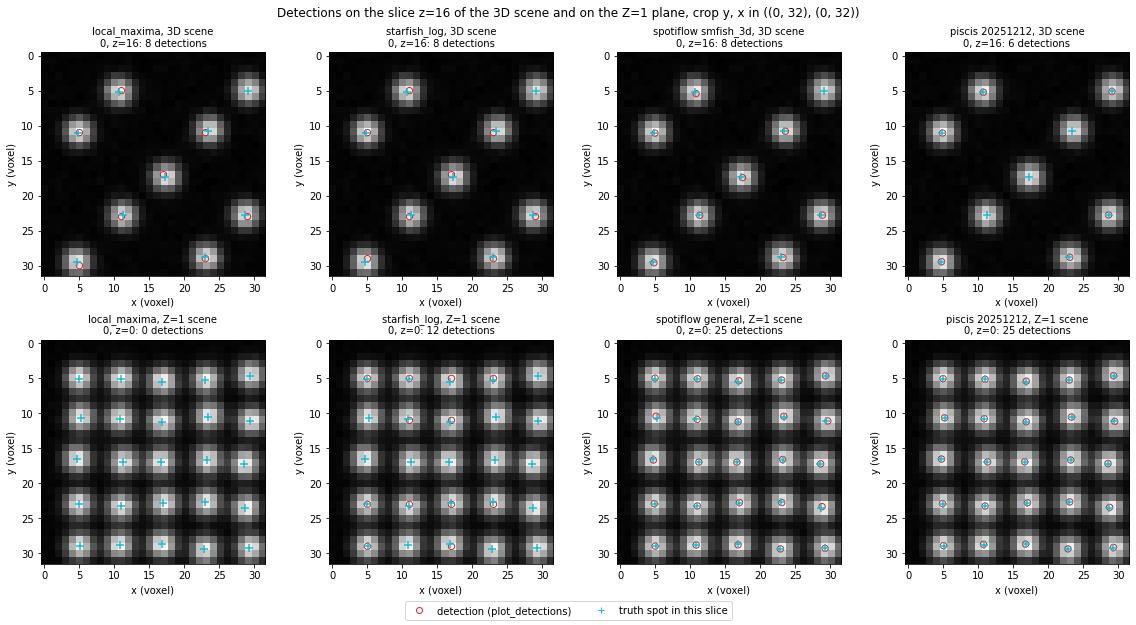

In [13]:
from matplotlib.lines import Line2D

from starfinder.spot_finding import plot_detections

SLICE = {"3D": int(LAYERS_Z[1]), "Z=1": 0}
WINDOW = ((0, 32), (0, 32))
FAMILIES = ("local_maxima", "starfish_log", "spotiflow", "piscis")
LEGEND = [Line2D([], [], marker="o", linestyle="", markerfacecolor="none", markeredgecolor="tab:red",
                 label="detection (plot_detections)"),
          Line2D([], [], marker="+", linestyle="", color="tab:cyan", label="truth spot in this slice")]
fig, axes = plt.subplots(2, len(FAMILIES), figsize=(16, 8.6), dpi=72, constrained_layout=True)
for row, case in enumerate(SHAPES):
    truth = truths[case]
    (y0, y1), (x0, x1) = WINDOW
    in_slice = ((np.rint(truth[:, 0]) == SLICE[case]) & (truth[:, 1] >= y0 - 0.5) & (truth[:, 1] < y1 - 0.5)
                & (truth[:, 2] >= x0 - 0.5) & (truth[:, 2] < x1 - 0.5))
    for column, family in enumerate(FAMILIES):
        label = next(name for name, c in RESULTS if c == case and name.split()[0] == family)
        axis = axes[row, column]
        plot_detections(images[case], RESULTS[label, case], channel=0, z=SLICE[case], yx_window=WINDOW, ax=axis)
        axis.scatter(truth[in_slice, 2], truth[in_slice, 1], marker="+", s=50, color="tab:cyan")
        axis.set_title(f"{label}, {case} scene\n{axis.get_title()}", fontsize=10)
        axis.set(xlabel="x (voxel)", ylabel="y (voxel)")
fig.legend(handles=LEGEND, loc="outside lower center", ncol=2)
fig.suptitle(f"Detections on the slice z={SLICE['3D']} of the 3D scene and on the Z=1 plane, crop y, x in {WINDOW}")
plt.show()

**Dimensionality, minimum shape and scale.** These rules are checked before a method runs,
and a violation raises a typed error instead of returning a silently empty or wrong
result ([docs/spot-finding-contract.md](../../docs/spot-finding-contract.md#z1-dimensionality-scale-and-tiling)):

* a Spotiflow 3D model on a Z=1 image, or a 2D model on a volume, raises
  `IncompatibleGeometryError` (there is no automatic switching between models);
* an image smaller than the registry's `min_shape_zyx` raises before the method runs, and a
  Spotiflow model has its own, larger minimum (from its known-weights row), below which
  Spotiflow would return nothing;
* the Starfish LoG detects a Z=1 image as a plane, so a per-axis (ZYX) sigma raises there;
* `scale` must be 1 for Spotiflow and Piscis: resampling is an explicit preprocessing step,
  and a config with any other value raises at construction;
* any device other than the CPU raises.

In [14]:
from starfinder.spot_finding import KNOWN_WEIGHTS

plane, volume = images["Z=1"], images["3D"]
print("smfish_3d minimum shape (known-weights row):", KNOWN_WEIGHTS["spotiflow", "smfish_3d"].min_shape_zyx,
      " spotiflow registry minimum:", SPOT_FINDING_METHODS[SpotiflowConfig].min_shape_zyx)


def run(image, config, **options):
    return find_spots(image, config=config, metadata=METADATA, spot_namespace=NAMESPACE, **options)


cases = {
    "3D model on the Z=1 plane": lambda: run(plane, SPOTIFLOW["3D"]),
    "2D model on the 3D scene": lambda: run(volume, SPOTIFLOW["Z=1"]),
    "below the registry minimum, shape (6, 64, 64)": lambda: run(volume[:6], SPOTIFLOW["3D"]),
    "below the model minimum, shape (7, 7, 7)": lambda: run(volume[:7, :7, :7], SPOTIFLOW["3D"]),
    "LoG with a ZYX sigma on the Z=1 plane": lambda: run(plane, replace(LOG, min_sigma=(1.0, 1.0, 1.0),
                                                                        max_sigma=(4.0, 4.0, 4.0))),
    "Spotiflow config with scale 2": lambda: replace(SPOTIFLOW["3D"], scale=2),
    "Piscis config with scale 0.5": lambda: replace(PISCIS, scale=0.5),
    "device 'cuda'": lambda: run(volume, LM, device="cuda"),
}
for name, call in cases.items():
    print(f"{name}:\n    {error_of(call)}")

smfish_3d minimum shape (known-weights row): (7, 8, 8)  spotiflow registry minimum: (7, 6, 6)
3D model on the Z=1 plane:
    IncompatibleGeometryError: spotiflow model 'smfish_3d' is a 3D model and returns nothing on a Z=1 image; a Z=1 image needs a 2D model (general, hybiss)
2D model on the 3D scene:
    IncompatibleGeometryError: spotiflow model 'general' is a 2D model and detects Z=1 images only; a volume needs a 3D model (synth_3d, smfish_3d)
below the registry minimum, shape (6, 64, 64):
    IncompatibleGeometryError: spotiflow requires 3D input with every axis at least (7, 6, 6), not (6, 64, 64)
below the model minimum, shape (7, 7, 7):
    IncompatibleGeometryError: spotiflow model 'smfish_3d' needs a ZYX shape of at least (7, 8, 8), not (7, 7, 7); Spotiflow would return nothing
LoG with a ZYX sigma on the Z=1 plane:
    IncompatibleGeometryError: starfish_log detects a Z=1 image as a YX plane, so min_sigma and max_sigma must be numbers, not ZYX 3-tuples
Spotiflow config with sc

## 4. Local maxima details

**Threshold modes and the noise record.** `threshold_mode` decides what `threshold_value`
means ([docs/spot-finding-baseline.md](../../docs/spot-finding-baseline.md)):

* `noise`: the channel's median plus `threshold_value` robust standard deviations (the MAD
  scaled to a Gaussian σ);
* `adaptive`: a fraction of the channel's maximum;
* `adaptive_round`: a fraction of the whole image's maximum, over all channels;
* `global`: a fraction of the dtype's maximum, for uint8 and uint16 images only.

In every mode, each channel's noise record (§2.5) is kept in `diagnostics["noise"]`: the
fraction of zero voxels, the median, the unscaled MAD and the threshold, computed in
float64. The cell runs each mode with the values `MODE_VALUES` (the ones the golden test
pins) on a two-channel version of the 3D scene whose second channel is the first scaled by
`DIM_FACTOR`, so that `adaptive` and `adaptive_round` differ.

In [15]:
MODE_VALUES = {"noise": 5.0, "adaptive": 0.2, "adaptive_round": 0.2, "global": 0.01}
DIM_FACTOR = 0.5
two = np.stack([volume, np.rint(volume * DIM_FACTOR).astype(np.uint16)], axis=-1)
print("MODE_VALUES:", MODE_VALUES, " DIM_FACTOR:", DIM_FACTOR, " image:", two.shape, two.dtype)
mode_rows = []
for mode, value in MODE_VALUES.items():
    result = run(two, LocalMaximaConfig(threshold_mode=mode, threshold_value=value, channel_labels=("bright", "dim")))
    for c, (label, record) in enumerate(result.diagnostics["noise"].items()):
        mode_rows.append(dict(mode=mode, threshold_value=value, channel=label, **record,
                              channel_max=int(two[..., c].max()), detections=result.diagnostics["counts"][label]))
pd.DataFrame(mode_rows).round(3)

MODE_VALUES: {'noise': 5.0, 'adaptive': 0.2, 'adaptive_round': 0.2, 'global': 0.01}  DIM_FACTOR: 0.5  image: (32, 64, 64, 2) uint16


,mode,threshold_value,channel,zero_fraction,median,mad,threshold,channel_max,detections
0,noise,5.00,bright,0.0,105.0,10.0,179.130,1651,100
1,noise,5.00,dim,0.0,52.0,5.0,89.065,826,100
2,adaptive,0.20,bright,0.0,105.0,10.0,330.200,1651,100
3,adaptive,0.20,dim,0.0,52.0,5.0,165.200,826,100
4,adaptive_round,0.20,bright,0.0,105.0,10.0,330.200,1651,100
5,adaptive_round,0.20,dim,0.0,52.0,5.0,330.200,826,100
6,global,0.01,bright,0.0,105.0,10.0,655.350,1651,100
7,global,0.01,dim,0.0,52.0,5.0,655.350,826,100


**The MAD-zero warning.** When a channel's MAD is 0, or more than half of its voxels are
zero (for example after background subtraction), the median and the MAD no longer measure
the noise. The detector then records the noise record as usual, keeps the threshold
unchanged (the golden test pins it) and emits a `SpotFindingWarning`, also listed in
`diagnostics["warnings"]`. The cell subtracts the `CLIP_PERCENTILE` percentile of the 3D
scene, clips at zero, which leaves most voxels zero, and detects in `noise` mode.

In [16]:
from starfinder.spot_finding import SpotFindingWarning

CLIP_PERCENTILE = 60
clipped = np.clip(volume.astype(np.int32) - int(np.percentile(volume, CLIP_PERCENTILE)), 0, None).astype(np.uint16)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    result = run(clipped, LM)
print("CLIP_PERCENTILE:", CLIP_PERCENTILE)
rule = " ".join(find_spots.__doc__.split())
print("the rule (find_spots docstring):", rule[rule.index("emits a SpotFindingWarning"):rule.index("the threshold is unchanged")]
      + "the threshold is unchanged.")
print("noise record:", result.diagnostics["noise"]["0"])
print("SpotFindingWarning raised:", [w.category.__name__ for w in caught if issubclass(w.category, SpotFindingWarning)])
print("diagnostics['warnings']:", result.diagnostics["warnings"])
print("detections:", len(result.spots), " truth spots:", len(truths["3D"]))

CLIP_PERCENTILE: 60
the rule (find_spots docstring): emits a SpotFindingWarning, also listed in diagnostics['warnings'], when a channel's MAD is 0 or more than half of its voxels are zero; the threshold is unchanged.
noise record: {'zero_fraction': 0.6036605834960938, 'median': 0.0, 'mad': 0.0, 'threshold': 0.0}
SpotFindingWarning raised: ['SpotFindingWarning']
diagnostics['warnings']: ("spot finding: channel '0': its noise MAD is 0 and 60.4% of its voxels are zero, so its median (0.0) and MAD do not measure its noise; the threshold 0.0 is unchanged",)
detections: 2071  truth spots: 100


With a threshold of zero, every local maximum of the clipped background is a detection;
the warning tells the user that the noise mode does not apply to this channel.

**The within-channel merge (`merge_radius_zyx`).** A plateau of equal pixel values (after
saturation or a coarse normalization) and a split amplicon give several maxima of one
amplicon in one channel. The opt-in field `merge_radius_zyx` (default `None`: the legacy
result, unchanged) merges them: after border exclusion, a channel's maxima are visited by
decreasing pixel value, then increasing z, y, x, and a maximum is dropped when an earlier
kept maximum of the same channel lies inside the ellipsoid Σ(Δᵢ/rᵢ)² ≤ 1. Kept maxima are
unchanged and nothing is averaged; `diagnostics["merged"]` counts the removed maxima per
channel ([docs/spot-finding-algorithms.md](../../docs/spot-finding-algorithms.md#local-maxima)).
The merge never looks across channels.

The cell builds the `small` benchmark scene of the §2.12 generator (four channels and four
rounds, with crosstalk from each channel into the next). It takes the reference round after
the legacy uint8 min-max normalization (recipe 1, `RECIPE1`), where plateaus appear, and
detects with and without the merge at `MERGE_RADIUS`. `classify_detections` then sorts the
detections into matched, duplicate (unmatched but within `CLASSIFY_RADIUS` of a matched
amplicon) and spurious, and splits the duplicates by channel into same-channel and
other-channel copies. The matching follows the validation's check S16 (`S16_MATCH`; only
amplicons whose centre lies inside the reference round are eligible).

In [17]:
from starfinder.evaluation.spot_finding import classify_detections
from starfinder.preprocessing import MinMaxNormalizationConfig, normalize_intensity
from starfinder.synthetic import formed_scene_preset

with timed("generate the small formed scene, 4 rounds (16, 256, 256, 4)"):
    book, small_config = formed_scene_preset("small")
    small = generate_formed_scene(book, config=small_config)
REFERENCE = small.round_labels[0]
small_round = small.rounds[REFERENCE]
small_metadata = small.round_metadata[REFERENCE]
in_round = small.round_truth.query("round_label == @REFERENCE").set_index("amplicon_id")
eligible = in_round.loc[small.formed.amplicon_id, "center_in_bounds"].to_numpy(dtype=bool)
amplicons = small.formed[["z", "y", "x"]].to_numpy(float)
RECIPE1 = MinMaxNormalizationConfig("uint8", (0, 255), rounding="truncate")
small_uint8 = normalize_intensity(small_round, config=RECIPE1)
MERGE_RADIUS = (2.0, 2.0, 2.0)
CLASSIFY_RADIUS = 5.0
S16_MATCH = dict(policy="greedy", threshold=5.0, boundary="exclusive", units="voxel")
print(f"small scene: rounds {small.round_labels} of {small_round.shape} {small_round.dtype}, channels "
      f"{small.channel_labels}; {len(amplicons)} amplicons, {int(eligible.sum())} eligible; seed {small_config.seed}")
print("RECIPE1:", RECIPE1)
print("MERGE_RADIUS:", MERGE_RADIUS, " CLASSIFY_RADIUS:", CLASSIFY_RADIUS, " S16_MATCH:", S16_MATCH)


def classified(image, config):
    result = find_spots(image, config=replace(config, channel_labels=small.channel_labels), metadata=small_metadata,
                        spot_namespace="tour/small")
    detected = result.spots[["z", "y", "x"]].to_numpy()
    matched = evaluate_spots(detected, amplicons, reference_metadata=small_metadata, observed_metadata=small_metadata,
                             eligible_reference=eligible, **S16_MATCH)
    counts = classify_detections(matched, detected, amplicons, radius=CLASSIFY_RADIUS,
                                 groups=result.spots.channel.to_numpy()).counts
    return result, matched, counts


merge_rows, merge_results = {}, {}
for name, config in (("merge_radius_zyx=None (legacy)", LM),
                     (f"merge_radius_zyx={MERGE_RADIUS}", replace(LM, merge_radius_zyx=MERGE_RADIUS))):
    result, matched, counts = classified(small_uint8, config)
    merge_results[name] = result
    merge_rows[name] = dict(detections=len(result.spots), **counts,
                            removed_per_channel=str(result.diagnostics.get("merged", "not recorded")))
merge_table = pd.DataFrame.from_dict(merge_rows, orient="index")
merge_table

small scene: rounds ('round1', 'round2', 'round3', 'round4') of (16, 256, 256, 4) uint16, channels ('ch00', 'ch01', 'ch02', 'ch03'); 50 amplicons, 50 eligible; seed 42
RECIPE1: MinMaxNormalizationConfig(output_dtype='uint8', output_range=(0, 255), scope='per_channel', snr_threshold=None, rounding='truncate')
MERGE_RADIUS: (2.0, 2.0, 2.0)  CLASSIFY_RADIUS: 5.0  S16_MATCH: {'policy': 'greedy', 'threshold': 5.0, 'boundary': 'exclusive', 'units': 'voxel'}


,detections,matched,duplicate,spurious,duplicate_same_group,duplicate_other_group,removed_per_channel
merge_radius_zyx=None (legacy),158,45,31,82,2,29,not recorded
"merge_radius_zyx=(2.0, 2.0, 2.0)",150,45,23,82,0,23,"{'ch00': 1, 'ch01': 2, 'ch02': 3, 'ch03': 2}"


The merge removes the same-channel duplicates without losing a match, and the
other-channel duplicates remain: they are the crosstalk copies of an amplicon in the next
channel, which local maxima detects there correctly. Removing them needs a decision across
channels (by channel ratio, by decoded color sequence, or by crosstalk compensation),
which belongs to the readout stage, §2.8. The figure shows one such amplicon of the merged
result: the same position detected in two neighbouring channels, each panel on the slice
of its own detection.

detection pairs in neighbouring channels within CLASSIFY_RADIUS: 31; the pair shown:
spot_id    z    y     x  channel  peak_intensity
      0 14.0 16.0 135.0        0           255.0
     26 13.0 16.0 135.0        1            17.0


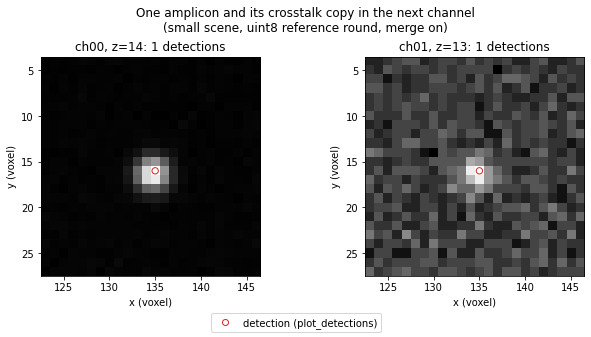

In [18]:
from scipy.spatial import cKDTree

merged = merge_results[f"merge_radius_zyx={MERGE_RADIUS}"]
spots = merged.spots
channel = spots.channel.to_numpy()
pairs = sorted((int(i), int(j)) for i, j in cKDTree(spots[["z", "y", "x"]].to_numpy()).query_pairs(CLASSIFY_RADIUS)
               if abs(channel[i] - channel[j]) == 1)
first, second = sorted(pairs[0], key=lambda k: channel[k])
centre = spots.loc[first, ["z", "y", "x"]].to_numpy().astype(int)
window = tuple((int(max(0, c - 12)), int(min(n, c + 12))) for c, n in zip(centre[1:], small_uint8.shape[1:3]))
print(f"detection pairs in neighbouring channels within CLASSIFY_RADIUS: {len(pairs)}; the pair shown:")
print(spots.loc[[first, second]].to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(9, 4.6), dpi=72, constrained_layout=True)
for axis, k in zip(axes, (first, second)):
    plot_detections(small_uint8, merged, channel=int(channel[k]), z=int(spots.z[k]), yx_window=window, ax=axis)
    axis.set(xlabel="x (voxel)", ylabel="y (voxel)")
fig.legend(handles=LEGEND[:1], loc="outside lower center")
fig.suptitle("One amplicon and its crosstalk copy in the next channel\n(small scene, uint8 reference round, merge on)")
plt.show()

**Border exclusion.** With `exclude_border=True` (the default), a maximum within
`min_distance_voxels` of a face is dropped, so an amplicon centred on a face is missed; the
field is settable in the workflow YAML since §2.7. The cell counts the eligible amplicons
of the `small` scene within `FACE_DISTANCE` voxels of a face, and how many of them each
setting misses, on the uint16 reference round as generated.

In [19]:
FACE_DISTANCE = 1
extent = np.asarray(small_round.shape[:3])
near_face = set(np.flatnonzero(eligible & (np.minimum(amplicons, extent - 1 - amplicons).min(axis=1) <= FACE_DISTANCE)).tolist())
print("FACE_DISTANCE:", FACE_DISTANCE, " eligible amplicons near a face:", len(near_face))
for exclude in (True, False):
    result, matched, counts = classified(small_round, replace(LM, exclude_border=exclude))
    found = {int(i) for i, _, _ in matched.details["matched_pairs"]}
    print(f"exclude_border={exclude!s:<5}: matched {counts['matched']} of {int(eligible.sum())} eligible, "
          f"near-face amplicons missed {len(near_face - found)}, detections {len(result.spots)}")

FACE_DISTANCE: 1  eligible amplicons near a face: 11


exclude_border=True : matched 45 of 50 eligible, near-face amplicons missed 5, detections 68


exclude_border=False: matched 50 of 50 eligible, near-face amplicons missed 0, detections 73


## 5. Starfish LoG

**Parity with starfish.** The Starfish LoG reproduces starfish's `BlobDetector` exactly.
The expected tables were produced by starfish itself on small fixtures and are saved as
test data (`src/python/test/data/starfish_blob_parity`: `fixtures.py` regenerates the
input arrays, and `starfish-tables.json` records each case's settings, array hash, column
order and dtypes). Starfinder's table maps to starfish's columns one to one: `intensity` is
the [0, 1]-scaled pixel value at the truncated position, `z, y, x` are the truncated
integers, `radius` is unchanged and `spot_id` is the row index. The cell regenerates the
two-channel volume fixture, checks its hash against the record, runs `find_spots` with the
recorded settings and compares one saved table with
`pandas.testing.assert_frame_equal(check_exact=True)`, printing both; the next cell repeats
the comparison for every saved table.

In [20]:
import hashlib
import importlib.util

from skimage import img_as_float32

PARITY = REPOSITORY / "src" / "python" / "test" / "data" / "starfish_blob_parity"
spec = importlib.util.spec_from_file_location("starfish_blob_parity_fixtures", PARITY / "fixtures.py")
parity_fixtures = importlib.util.module_from_spec(spec)
spec.loader.exec_module(parity_fixtures)
RECORD = json.loads((PARITY / "starfish-tables.json").read_text())
print("starfish version of the saved tables:", RECORD["starfish_version"])


def parity_case(case):
    # (ZYXC float32 image, StarfishLogConfig, record entry) of one saved parity case; the array hash is checked.
    entry = RECORD["cases"][case]
    array, _ = parity_fixtures.fixture(entry["fixture"])
    assert hashlib.sha256(array.tobytes()).hexdigest() == entry["array_sha256"]
    settings = {k: tuple(v) if isinstance(v, list) else v for k, v in entry["settings"].items()}
    return np.moveaxis(array[0], 0, -1), StarfishLogConfig(**settings), entry


def starfish_columns(spots, channel_image):
    # One channel's rows of a starfish_log table in starfish's columns.
    z, y, x = (spots[a].to_numpy().astype(np.int64) for a in "zyx")
    return pd.DataFrame({"intensity": img_as_float32(channel_image)[z, y, x], "z": z, "y": y, "x": x,
                         "radius": spots["radius"].to_numpy(), "spot_id": np.arange(len(spots), dtype=np.int64)})


def saved_table(table):
    frame = pd.read_csv(PARITY / table["csv"])[table["columns"]]
    if len(frame):
        return frame.astype(table["dtypes"])
    return pd.DataFrame({k: pd.Series([], dtype=v) for k, v in table["dtypes"].items()})[table["columns"]]


def compare(case, key):
    image, config, entry = parity_case(case)
    result = find_spots(image, config=config, metadata=METADATA, spot_namespace="tour/parity")
    c = int(key.split("_c")[1])
    ours = starfish_columns(result.spots[result.spots.channel == c], image[..., c])
    expected = saved_table(entry["tables"][key])
    if not len(expected):
        ours = ours[list(expected.columns)].astype(expected.dtypes.to_dict())
    pd.testing.assert_frame_equal(ours, expected, check_exact=True)
    return ours, expected, config


CASE, KEY = "volume-2ch-isotropic", "r0_c0"
ours, expected, config = compare(CASE, KEY)
print(f"case {CASE}, table {KEY}, image {parity_case(CASE)[0].shape}: {config}")
print("\nsaved starfish table:")
print(expected.to_string(index=False))
print("\nStarfinder's table in starfish's columns:")
print(ours.to_string(index=False))
print("\nassert_frame_equal(check_exact=True) passed; frames equal:", ours.equals(expected))

starfish version of the saved tables: 0.4.0+38.g1fb00cb


case volume-2ch-isotropic, table r0_c0, image (16, 64, 64, 2): StarfishLogConfig(min_sigma=1, max_sigma=10, num_sigma=30, threshold=0.01, overlap=0.5, exclude_border=False, channel_labels=None, method='starfish_log')

saved starfish table:
 intensity  z  y  x  radius  spot_id
  0.799234  8 32 31     2.0        0
  0.759279  8 45  6     2.0        1
  0.640367  8 39 22     2.0        2
  0.621479  6  9 24     2.0        3
  0.607980  5 23  8     2.0        4
  0.588199 11 28 27     2.0        5
  0.499541  4 55 19     2.0        6
  0.454642  7 12 45     2.0        7
  0.420691  7  4 35     2.0        8

Starfinder's table in starfish's columns:
 intensity  z  y  x  radius  spot_id
  0.799234  8 32 31     2.0        0
  0.759279  8 45  6     2.0        1
  0.640367  8 39 22     2.0        2
  0.621479  6  9 24     2.0        3
  0.607980  5 23  8     2.0        4
  0.588199 11 28 27     2.0        5
  0.499541  4 55 19     2.0        6
  0.454642  7 12 45     2.0        7
  0.420691  7 

In [21]:
for case, entry in RECORD["cases"].items():
    for key, table in entry["tables"].items():
        ours, expected, _ = compare(case, key)
        print(f"{case:<24} {key}: {len(ours):>2} rows (saved {table['rows']}), equal with check_exact=True")

volume-2ch-isotropic     r0_c0:  9 rows (saved 9), equal with check_exact=True


volume-2ch-isotropic     r0_c1:  8 rows (saved 8), equal with check_exact=True


volume-2ch-anisotropic   r0_c0:  9 rows (saved 9), equal with check_exact=True


volume-2ch-anisotropic   r0_c1:  8 rows (saved 8), equal with check_exact=True
plane-isotropic          r0_c0: 11 rows (saved 11), equal with check_exact=True
empty-isotropic          r0_c0:  0 rows (saved 0), equal with check_exact=True


**Intensity scaling.** Starfish holds images as float32 in [0, 1], so the LoG scales an
integer image by its dtype maximum (`img_as_float32`), and a float image must already lie
in [0, 1]. The cell first shows that the uint16 3D scene and its explicitly scaled float32
copy give the same positions and radii (`peak_intensity` keeps each input's own pixel
values), and that a float image outside [0, 1] raises.

**Threshold units.** `threshold` is absolute, on the scale-normalized LoG response of the
scaled image, so its meaning depends on the dtype and the spot amplitude. A spot of
brightness `BRIGHTNESS` in uint16 has a small scaled amplitude, and its response is close
to the tutorial threshold. The cell evaluates the response as `blob_log` builds its scale
space (the maximum over the config's sigma list of `−σ²·∇²G_σ` of the scaled image) at the
truth positions of each scene, and counts the spots whose response is above the
threshold. That fraction is close to the LoG recall of section 3: in 3D every spot stands
above the threshold, while on the plane many fall below, so a threshold value does not
transfer between images or scalings.

In [22]:
from scipy.ndimage import gaussian_laplace

log_uint16 = RESULTS["starfish_log", "3D"].spots
log_float = run(img_as_float32(volume), LOG).spots
columns = ["spot_id", "z", "y", "x", "channel", "radius"]
print("uint16 and scaled float32 give the same positions and radii:", log_uint16[columns].equals(log_float[columns]))
print(error_of(lambda: run(volume.astype(np.float32), LOG)))

sigmas = np.linspace(LOG.min_sigma, LOG.max_sigma, LOG.num_sigma)
dtype_max = np.iinfo(np.uint16).max
print(f"\nscaled amplitude of a spot: BRIGHTNESS / {dtype_max} = {BRIGHTNESS / dtype_max:.4f}; LOG.threshold {LOG.threshold}")
for case in SHAPES:
    signal = img_as_float32(images[case]).astype(np.float64)
    points = np.rint(truths[case]).astype(int)
    if case == "Z=1":
        signal, points = signal[0], points[:, 1:]
    response = np.max([-(s ** 2) * gaussian_laplace(signal, s)[tuple(points.T)] for s in sigmas], axis=0)
    recall = results_table.query("method == 'starfish_log' and scene == @case").recall.item()
    print(f"{case:>4}: response at the truth spots: median {np.median(response):.4f}, min {response.min():.4f}, "
          f"max {response.max():.4f}; fraction above the threshold {np.mean(response > LOG.threshold):.2f}; "
          f"LoG recall in section 3 {recall:.2f}")

uint16 and scaled float32 give the same positions and radii: True
ValueError: starfish_log needs intensities in [0, 1]: integer images are scaled by their dtype maximum, and a float image must already lie in [0, 1] (this channel spans [61.0, 1651.0])

scaled amplitude of a spot: BRIGHTNESS / 65535 = 0.0229; LOG.threshold 0.01


  3D: response at the truth spots: median 0.0117, min 0.0109, max 0.0127; fraction above the threshold 1.00; LoG recall in section 3 1.00
 Z=1: response at the truth spots: median 0.0099, min 0.0090, max 0.0111; fraction above the threshold 0.43; LoG recall in section 3 0.43


**The scale-space memory estimate.** `blob_log` holds the whole scale space, one LoG image
per sigma, so its memory grows with `num_sigma` times the number of voxels. Before it runs,
the detector records the estimate `geometry["scale_space_bytes_estimate"]` (a measured
number of bytes per voxel and scale, times `num_sigma`, times the voxels of one channel);
it records the estimate and does not enforce it. The cell reads the estimate for the
values `NUM_SIGMAS` on the 3D scene and on one channel of the `small` scene (a constant
image of that shape, which yields the estimate without running `blob_log`), and measures
the peak NumPy allocation of an actual detection on the 3D scene with `tracemalloc`.

In [23]:
import tracemalloc

NUM_SIGMAS = (10, 30)
memory_rows = []
for num_sigma in NUM_SIGMAS:
    config = replace(LOG, num_sigma=num_sigma)
    tracemalloc.start()
    geometry = run(volume, config).diagnostics["geometry"]
    peak = tracemalloc.get_traced_memory()[1]
    tracemalloc.stop()
    small_geometry = run(np.zeros(small_round.shape[:3], dtype=np.uint16), config).diagnostics["geometry"]
    memory_rows.append(dict(num_sigma=num_sigma, bytes_per_voxel_and_sigma=geometry["bytes_per_voxel_and_sigma"],
                            voxels_3D=geometry["voxels"], estimate_3D_MB=geometry["scale_space_bytes_estimate"] / 1e6,
                            traced_peak_3D_MB=peak / 1e6, voxels_small=small_geometry["voxels"],
                            estimate_small_MB=small_geometry["scale_space_bytes_estimate"] / 1e6))
pd.DataFrame(memory_rows).round(1)

,num_sigma,bytes_per_voxel_and_sigma,voxels_3D,estimate_3D_MB,traced_peak_3D_MB,voxels_small,estimate_small_MB
0,10,10.4,131072,13.6,13.6,1048576,109.1
1,30,10.4,131072,40.9,39.9,1048576,327.2


## 6. Pretrained weights

Starfinder manages the weights of the learned methods itself
([docs/spot-finding-contract.md](../../docs/spot-finding-contract.md#pretrained-weights)).
`KNOWN_WEIGHTS` lists every model Starfinder can fetch and verify, with the SHA-256 of
every file, the source and the revision, and sets no default. The cache is
`$STARFINDER_WEIGHTS_DIR` (else `$XDG_CACHE_HOME/starfinder/weights`), with one folder per
`<method>/<model>`. Weights are fetched only by the explicit command `starfinder weights
fetch <method> <model>` (or `fetch_weights`), the only code that uses the network. Every
detection re-hashes every listed file of its model and then builds the model from those
files through an absolute path, never through the libraries' own caches.

The cell runs `starfinder weights list` and `starfinder weights verify` on the local cache
as a user would, in a subprocess, with the cache written relative to
`$STARFINDER_WEIGHTS_DIR`.

In [24]:
import subprocess


def weights_command(*arguments):
    completed = subprocess.run([sys.executable, "-m", "starfinder", "weights", *arguments], capture_output=True,
                               text=True, env=dict(os.environ))
    print(f"$ starfinder weights {' '.join(arguments)}   (exit status {completed.returncode})")
    print(clean(completed.stdout + completed.stderr).rstrip())


weights_command("list")
print()
with timed("starfinder weights verify (re-hash every local model)"):
    weights_command("verify")

$ starfinder weights list   (exit status 0)
weights directory: $STARFINDER_WEIGHTS_DIR
spotiflow	synth_3d	3D	263107693 bytes	sha256 2468125c8c1a8bb6f6364f439d50ff08e24a15e6fa4c0c2cf43b26667393038b	spotiflow-models release 0.6.0	fetched
spotiflow	smfish_3d	3D	263106200 bytes	sha256 a6c79f767eaddff7e4c85ba370b370ffdb752829ea0a06d7ca71e5556b554775	spotiflow-models release 0.6.0	fetched
spotiflow	general	2D	87885382 bytes	sha256 1da93a8282fedab697dbb9f5c24f623e452063b296ffaad9becd0afdc7bd2797	spotiflow-models release 0.6.0	fetched
spotiflow	hybiss	2D	87945684 bytes	sha256 d6221339a104cddfac77b3b8a1014bd316a7060934d69bc078f5a653cb72658b	spotiflow-models release 0.6.0	fetched
piscis	20230905	2D network; stack mode links planes	30077822 bytes	sha256 57177963f50af929d68c8a2e5797bb966cb7bc43806f8c1efe9f7131b6449f19	wniu/Piscis 9bdefc72cb519053c63fd2d7bff9d12db7bb394e	fetched
piscis	20251212	2D network; stack mode links planes	30143014 bytes	sha256 e4ec9fe68e43fe955001e3bf2317badfc4c418027910e77

$ starfinder weights verify   (exit status 0)
spotiflow	synth_3d	verified	$STARFINDER_WEIGHTS_DIR/spotiflow/synth_3d
spotiflow	smfish_3d	verified	$STARFINDER_WEIGHTS_DIR/spotiflow/smfish_3d
spotiflow	general	verified	$STARFINDER_WEIGHTS_DIR/spotiflow/general
spotiflow	hybiss	verified	$STARFINDER_WEIGHTS_DIR/spotiflow/hybiss
piscis	20230905	verified	$STARFINDER_WEIGHTS_DIR/piscis/20230905
piscis	20251212	verified	$STARFINDER_WEIGHTS_DIR/piscis/20251212


**The known-weights table.** For each model the table gives its dimensionality, the
SHA-256 and source of the download, the revision, the training pixel size (as retrieved, or
"not published by the authors"), the observed minimum input shape, the native threshold
(stored with the weights, or the library's default) and the files the library loads.

In [25]:
known = pd.DataFrame([dict(method=e.method, model=e.model, dimensionality=e.dimensionality, sha256=e.sha256,
                           source=e.url, revision=e.revision, training_pixel_size=e.training_pixel_size,
                           min_shape_zyx=e.min_shape_zyx, native_threshold=round(e.native_threshold, 4),
                           loaded_files=", ".join(f.path for f in e.files))
                      for e in KNOWN_WEIGHTS.values()])
with pd.option_context("display.max_colwidth", 100):
    display(known)

,method,model,dimensionality,sha256,source,revision,training_pixel_size,min_shape_zyx,native_threshold,loaded_files
0,spotiflow,synth_3d,3D,2468125c8c1a8bb6f6364f439d50ff08e24a15e6fa4c0c2cf43b26667393038b,https://github.com/weigertlab/spotiflow-models/releases/download/0.6.0/synth_3d.zip,spotiflow-models release 0.6.0,0.2 um voxels (synthetic),"(7, 8, 8)",0.300,best.pt
1,spotiflow,smfish_3d,3D,a6c79f767eaddff7e4c85ba370b370ffdb752829ea0a06d7ca71e5556b554775,https://github.com/weigertlab/spotiflow-models/releases/download/0.6.0/smfish_3d.zip,spotiflow-models release 0.6.0,"0.13 um YX, 0.48 um Z","(7, 8, 8)",0.400,best.pt
2,spotiflow,general,2D,1da93a8282fedab697dbb9f5c24f623e452063b296ffaad9becd0afdc7bd2797,https://github.com/weigertlab/spotiflow-models/releases/download/0.6.0/general.zip,spotiflow-models release 0.6.0,"0.04, 0.1, 0.11, 0.15, 0.32 and 0.34 um (mixed training data)","(1, 6, 6)",0.500,best.pt
3,spotiflow,hybiss,2D,d6221339a104cddfac77b3b8a1014bd316a7060934d69bc078f5a653cb72658b,https://github.com/weigertlab/spotiflow-models/releases/download/0.6.0/hybiss.zip,spotiflow-models release 0.6.0,"0.15, 0.32 and 0.34 um","(1, 6, 6)",0.532,best.pt
4,piscis,20230905,2D network; stack mode links planes,57177963f50af929d68c8a2e5797bb966cb7bc43806f8c1efe9f7131b6449f19,https://huggingface.co/wniu/Piscis/resolve/9bdefc72cb519053c63fd2d7bff9d12db7bb394e/models/20230...,wniu/Piscis 9bdefc72cb519053c63fd2d7bff9d12db7bb394e,not published by the authors,"(2, 1, 1)",0.500,20230905.pt
5,piscis,20251212,2D network; stack mode links planes,e4ec9fe68e43fe955001e3bf2317badfc4c418027910e7762a37f52d7e64d06f,https://huggingface.co/wniu/Piscis/resolve/9bdefc72cb519053c63fd2d7bff9d12db7bb394e/models/20251...,wniu/Piscis 9bdefc72cb519053c63fd2d7bff9d12db7bb394e,not published by the authors,"(2, 1, 1)",0.500,20251212.pt


**The errors, on a temporary copy.** The cell copies one model folder into a temporary
cache and shows the errors there, never on the real cache. The copy verifies; after one
byte of the weights file changes, `resolve_weights` raises `WeightsHashMismatchError` with
both hashes; after the file is removed, it raises `MissingWeightsError` with the expected
path and the fetch command. A detection that uses the temporary cache raises the same error
instead of downloading, and an unknown model name raises at construction, listing the
known ones.

In [26]:
import shutil

from starfinder.spot_finding import resolve_weights

COPY = WORKSPACE / "weights"
shutil.copytree(WEIGHTS / "piscis" / PISCIS.model, COPY / "piscis" / PISCIS.model)
weights_file = COPY / "piscis" / PISCIS.model / KNOWN_WEIGHTS["piscis", PISCIS.model].files[0].path
print("the copy verifies:", clean(resolve_weights("piscis", PISCIS.model, directory=COPY)))
data = bytearray(weights_file.read_bytes())
data[len(data) // 2] ^= 1
weights_file.write_bytes(bytes(data))
print("one byte changed:\n   ", error_of(lambda: resolve_weights("piscis", PISCIS.model, directory=COPY)))
weights_file.unlink()
print("file removed:\n   ", error_of(lambda: resolve_weights("piscis", PISCIS.model, directory=COPY)))

previous = os.environ["STARFINDER_WEIGHTS_DIR"]
os.environ["STARFINDER_WEIGHTS_DIR"] = str(COPY)
try:
    print("a detection with this cache:\n   ", error_of(lambda: run(plane, PISCIS)))
finally:
    os.environ["STARFINDER_WEIGHTS_DIR"] = previous
print("an unknown model:\n   ", error_of(lambda: PiscisConfig("latest")))
print("the real cache still verifies:", clean(resolve_weights("piscis", PISCIS.model)))

the copy verifies: <workspace>/weights/piscis/20251212


one byte changed:
    WeightsHashMismatchError: piscis model '20251212': <workspace>/weights/piscis/20251212/20251212.pt has SHA-256 e8907cb3e3138aa3aecfefd551f6aa3e3bf2409eb9088cce550e8236909b1caf, expected e4ec9fe68e43fe955001e3bf2317badfc4c418027910e7762a37f52d7e64d06f
file removed:
    MissingWeightsError: piscis model '20251212': weights file <workspace>/weights/piscis/20251212/20251212.pt is missing; fetch it with 'starfinder weights fetch piscis 20251212 --dir <workspace>/weights'
a detection with this cache:
    MissingWeightsError: piscis model '20251212': weights file <workspace>/weights/piscis/20251212/20251212.pt is missing; fetch it with 'starfinder weights fetch piscis 20251212'
an unknown model:
    ValueError: unknown piscis model 'latest'; known models: ['20230905', '20251212']
the real cache still verifies: $STARFINDER_WEIGHTS_DIR/piscis/20251212


**`FOV.run` never downloads.** `find_spots`, `FOV.find_spots` and `FOV.run` only resolve
and verify weights in the cache, and the download code lives in a module that detection
never imports. After every detection so far, that module has not been imported in this
kernel (the `weights` commands above ran in their own processes); the cell checks it again
after the `FOV.run` of section 8.

In [27]:
FETCH_MODULE = "starfinder.spot_finding._fetch"
print("download module imported in this kernel:", FETCH_MODULE in sys.modules)

download module imported in this kernel: False


## 7. Detection in several rounds and the candidates checkpoint

By default the pipeline detects in the reference round only. `SpotFindingPlan(config,
rounds=...)` names the rounds to detect in
([docs/spot-finding-contract.md](../../docs/spot-finding-contract.md#detection-in-several-rounds)).
`FOV.find_spots` and `FOV.run` then detect each listed round's image on the reference grid
(after its registration) and give **one** result with a `round` column, the rounds in run
order (reference first). `spot_id` runs over the combined table, rows of different rounds
are never merged, joins use `(spot_namespace, spot_id)`, and the per-round diagnostics move
under `diagnostics["rounds"]`. Direct `find_spots` detects one image, so it accepts only a
plan without rounds.

The cell hand-builds a small multi-round scene as the validation's `multiround` fixture
does: the rounds `MULTI_ROUNDS` of shape `MULTI_SHAPE` with the channels `MULTI_CHANNELS`
on one grid, `N_PER_ROUND` spots per round and channel on a lattice of sites, `N_SHARED` of
them at the same positions in every round, with the isolated-spot appearance.

In [28]:
from starfinder.dataset import CheckpointConfig, Dataset, RoundState

MULTI_SHAPE, MULTI_ROUNDS, MULTI_CHANNELS = (16, 64, 64), ("round1", "round2", "round3"), ("ch00", "ch01")
SITES = np.array([(z, y, x) for z in (4, 11) for y in range(7, 57, 7) for x in range(7, 57, 7)], dtype=float)
N_SHARED, N_PER_ROUND = 5, 15
GRID = ImageMetadata("tour/multiround")


def render(rng, centres):
    z, y, x = np.meshgrid(*(np.arange(n, dtype=np.float64) for n in MULTI_SHAPE), indexing="ij")
    signal = np.full(MULTI_SHAPE, BASELINE)
    for cz, cy, cx in centres:
        signal += BRIGHTNESS * np.exp(-((z - cz) / SIGMA_Z) ** 2 / 2 - ((y - cy) / SIGMA_YX) ** 2 / 2
                                      - ((x - cx) / SIGMA_YX) ** 2 / 2)
    return np.clip(np.rint(rng.poisson(signal) + rng.normal(0.0, READ_NOISE, MULTI_SHAPE)), 0, 65535).astype(np.uint16)


rng = np.random.default_rng(SEED)
shared, unique = [], []
for _ in MULTI_CHANNELS:
    order = rng.permutation(len(SITES))
    shared.append(SITES[order[:N_SHARED]])
    per_round = N_PER_ROUND - N_SHARED
    unique.append([SITES[order[N_SHARED + i * per_round:N_SHARED + (i + 1) * per_round]] for i in range(len(MULTI_ROUNDS))])
multi_images = {name: np.stack([render(rng, np.vstack([shared[c], unique[c][r]])) for c in range(len(MULTI_CHANNELS))],
                               axis=-1) for r, name in enumerate(MULTI_ROUNDS)}


def multiround_fov(name, with_images=True):
    dataset = Dataset(WORKSPACE / name / "input", WORKSPACE / name / "output", "tour", "multiround", name,
                      rounds=RoundState(sequencing_rounds=list(MULTI_ROUNDS), reference_round=MULTI_ROUNDS[0]),
                      channel_order=list(MULTI_CHANNELS))
    fov = dataset.fov("FOV_001")
    for round_name, image in multi_images.items() if with_images else ():
        fov.images[round_name] = image.copy()
        fov.metadata[round_name] = GRID
    return fov


print("rounds:", {name: (image.shape, str(image.dtype)) for name, image in multi_images.items()})
print(f"N_PER_ROUND {N_PER_ROUND}, N_SHARED {N_SHARED}; lattice of {len(SITES)} sites; "
      f"density {N_PER_ROUND / np.prod(MULTI_SHAPE):.2g} per voxel per round and channel; seed {SEED}")

rounds: {'round1': ((16, 64, 64, 2), 'uint16'), 'round2': ((16, 64, 64, 2), 'uint16'), 'round3': ((16, 64, 64, 2), 'uint16')}
N_PER_ROUND 15, N_SHARED 5; lattice of 128 sites; density 0.00023 per voxel per round and channel; seed 100


In [29]:
ROUND_PLAN = SpotFindingPlan(LM, rounds=MULTI_ROUNDS)
fov = multiround_fov("rounds").find_spots(config=ROUND_PLAN)
default = multiround_fov("default").find_spots(config=LM)
spots = fov.spot_result.spots
show(fov.spot_result)
print("round dtype:", spots["round"].dtype, " rounds in order:", list(dict.fromkeys(spots["round"])))
print("spot_id is '0'..'N-1':", spots.spot_id.tolist() == [str(i) for i in range(len(spots))],
      " namespace:", fov.spot_result.spot_namespace)
print("rows per round and channel:")
print(spots.groupby(["round", "channel"]).size().unstack().to_string())
print("diagnostics['rounds']:", {name: sorted(entry) for name, entry in fov.spot_result.diagnostics["rounds"].items()})
reference_rows = spots[spots["round"] == MULTI_ROUNDS[0]].drop(columns="round").reset_index(drop=True)
print("reference-round rows equal the default (reference-only) table:", reference_rows.equals(default.spot_result.spots))

found = []
for c in range(len(MULTI_CHANNELS)):
    rows = spots[spots.channel == c]
    zyx = rows[["z", "y", "x"]].to_numpy()
    for centre in shared[c]:
        near = rows[np.linalg.norm(zyx - centre, axis=1) <= MATCH["threshold"]]
        found.append(dict(channel=MULTI_CHANNELS[c], shared_centre=tuple(int(v) for v in centre), rows=len(near),
                          rounds=list(near["round"]), spot_ids=list(near.spot_id)))
print(f"\nrows within MATCH['threshold'] = {MATCH['threshold']} voxels of each shared position:")
pd.DataFrame(found)

SpotFindingResult: 90 spots × [spot_id, z, y, x, ...]
round dtype: string  rounds in order: ['round1', 'round2', 'round3']
spot_id is '0'..'N-1': True  namespace: ["tour","multiround","FOV_001",null]
rows per round and channel:
channel   0   1
round          
round1   15  15
round2   15  15
round3   15  15
diagnostics['rounds']: {'round1': ['counts', 'noise', 'outcomes', 'thresholds'], 'round2': ['counts', 'noise', 'outcomes', 'thresholds'], 'round3': ['counts', 'noise', 'outcomes', 'thresholds']}
reference-round rows equal the default (reference-only) table: True

rows within MATCH['threshold'] = 3.0 voxels of each shared position:


,channel,shared_centre,rows,rounds,spot_ids
0,ch00,"(4, 49, 14)",3,"[round1, round2, round3]","[0, 30, 62]"
1,ch00,"(11, 21, 7)",3,"[round1, round2, round3]","[8, 36, 65]"
2,ch00,"(11, 28, 7)",3,"[round1, round2, round3]","[13, 35, 68]"
3,ch00,"(4, 56, 42)",3,"[round1, round2, round3]","[5, 33, 66]"
4,ch00,"(4, 56, 49)",3,"[round1, round2, round3]","[2, 40, 64]"
5,ch01,"(4, 14, 42)",3,"[round1, round2, round3]","[29, 51, 79]"
6,ch01,"(4, 42, 28)",3,"[round1, round2, round3]","[19, 48, 83]"
7,ch01,"(4, 7, 49)",3,"[round1, round2, round3]","[15, 56, 81]"
8,ch01,"(11, 28, 7)",3,"[round1, round2, round3]","[28, 54, 88]"
9,ch01,"(4, 56, 28)",3,"[round1, round2, round3]","[16, 53, 75]"


**The decoding guard.** Barcode decoding reads one candidate per amplicon and every round's
intensity there. A candidate set detected in several rounds holds several rows per
amplicon, and how to read them out (a readout mode) is decided in §2.8. Until then,
decoding such a set raises `ValueError` naming §2.8, both in `decode_barcodes` and in
`FOV.run` before anything is processed.

In [30]:
from starfinder.barcode import NeighborhoodSumConfig, WtaDecoderConfig

print(error_of(fov.decode_barcodes))
guarded = multiround_fov("guard")
print(error_of(lambda: guarded.run(PipelineConfig(detection=ROUND_PLAN, extraction=NeighborhoodSumConfig(),
                                                  decoding=WtaDecoderConfig()))))
print("no result after the refused run:", guarded.spot_result is None)

[FOV_001] Failed decode_barcodes: decoding candidates from several detection rounds needs a readout mode (§2.8)


[FOV_001] Failed run: decoding candidates from several detection rounds needs a readout mode (§2.8)


ValueError: decoding candidates from several detection rounds needs a readout mode (§2.8)
ValueError: decoding candidates from several detection rounds needs a readout mode (§2.8)
no result after the refused run: True


**The candidates checkpoint.** With `CheckpointConfig(stages=("candidates",))`, `FOV.run`
writes the candidate table (CSV or Parquet) and `candidates.json`, which records the
detector config, the plan's overrides (`detection_plan`), the rounds (`detection_rounds`),
the execution entry, the loaded weights files and the column dtypes, including the `round`
column ([docs/checkpoints.md](../../docs/checkpoints.md#candidates)). The cell runs the
round plan with one channel override through `FOV.run`, lists the files, prints the header
entries, and reloads the checkpoint into a fresh FOV: the table, config, plan and per-round
diagnostics come back identical.

In [31]:
CHECKPOINTS = WORKSPACE / "multiround-checkpoints"
override_plan = SpotFindingPlan(LM, (ChannelOverride("ch01", replace(LM, threshold_value=6.0)),), MULTI_ROUNDS)
written = multiround_fov("checkpoint")
written.run(PipelineConfig(detection=override_plan),
            checkpoints=CheckpointConfig(stages=("candidates",), directory=CHECKPOINTS, table_format="csv"))
for path in sorted(CHECKPOINTS.rglob("*")):
    if path.is_file():
        print(clean(path))
header = json.loads((CHECKPOINTS / "FOV_001" / "candidates.json").read_text())
print("\ncandidates.json format_version:", header["format_version"])
print("detection_rounds:", header["detection_rounds"])
print("detection_plan:", header["detection_plan"])
print("execution device:", header["execution"]["device"], " weights:", header["weights"],
      " round dtype:", header["dtypes"]["round"])

reloaded = multiround_fov("reloaded", with_images=False)
reloaded.load_checkpoint("candidates", checkpoints=CheckpointConfig(directory=CHECKPOINTS))
pd.testing.assert_frame_equal(reloaded.spot_result.spots, written.spot_result.spots, check_exact=True)
print("\nreloaded table: assert_frame_equal(check_exact=True) passed;",
      "frames equal:", reloaded.spot_result.spots.equals(written.spot_result.spots))
print("config equal:", reloaded.spot_result.config == written.spot_result.config,
      " plan equal:", reloaded.spot_result.plan == written.spot_result.plan,
      " per-round diagnostics equal:", reloaded.spot_result.diagnostics["rounds"] == written.spot_result.diagnostics["rounds"])

<workspace>/multiround-checkpoints/FOV_001/candidates.csv
<workspace>/multiround-checkpoints/FOV_001/candidates.json
<workspace>/multiround-checkpoints/FOV_001/run.json

candidates.json format_version: 2
detection_rounds: ['round1', 'round2', 'round3']
detection_plan: [{'channel': 'ch01', 'config': {'threshold_mode': 'noise', 'threshold_value': 6.0, 'min_distance_voxels': 1, 'exclude_border': True, 'channel_labels': None, 'measure_peak_intensity': True, 'merge_radius_zyx': None, 'method': 'local_maxima'}}]
execution device: cpu  weights: []  round dtype: string

reloaded table: assert_frame_equal(check_exact=True) passed; frames equal: True
config equal: True  plan equal: True  per-round diagnostics equal: True


## 8. One field of view through `FOV.run`

In the pipeline, detection is one stage of `PipelineConfig`. `FOV.run` validates the whole
configuration first, checks the device of its `ExecutionConfig`, fills each config's
`channel_labels` from `Dataset.channel_order`, and records every detection in the run
record `run.json`: the detection's step record gets a **provenance entry** under `methods`,
with the stage, the method, the config type and its fields, the implementation, the
versions of the declared dependencies, the loaded weights files as `artifacts`, and the
execution entry. The cell runs a Spotiflow plan with one channel override on the reference
round of the multi-round scene and prints that entry, with the weights paths relative to
the cache.

In [32]:
RUN = WORKSPACE / "run-checkpoints"
run_plan = SpotFindingPlan(SpotiflowConfig("smfish_3d"),
                           (ChannelOverride("ch01", SpotiflowConfig("smfish_3d", prob_thresh=0.5)),))
run_fov = multiround_fov("run")
with timed(f"FOV.run with a Spotiflow plan, {len(MULTI_CHANNELS)} channels of {MULTI_SHAPE}"):
    run_fov.run(PipelineConfig(detection=run_plan), execution=ExecutionConfig(device="cpu"),
                checkpoints=CheckpointConfig(stages=("candidates",), directory=RUN))
show(run_fov.spot_result)
print("effective prob_thresh per channel:",
      {label: s["prob_thresh"] for label, s in run_fov.spot_result.diagnostics["effective_settings"].items()})
record = json.loads((RUN / "FOV_001" / "run.json").read_text())
print("run.json status:", record["status"], " steps:", [s["name"] for s in record["steps"]])
step = next(s for s in record["steps"] if s.get("methods"))
print(f"step {step['name']!r}: provenance entry")
print(clean(json.dumps(step["methods"][0], indent=1)))
print("\ndownload module imported in this kernel after FOV.run:", FETCH_MODULE in sys.modules)

SpotFindingResult: 30 spots × [spot_id, z, y, x, ...]
effective prob_thresh per channel: {'ch00': 0.4, 'ch01': 0.5}
run.json status: succeeded  steps: ['find_spots', 'write_checkpoint:candidates']
step 'find_spots': provenance entry
{
 "stage": "spot_finding",
 "method": "spotiflow",
 "config_type": "starfinder.spot_finding.SpotiflowConfig",
 "implementation": "starfinder.spot_finding._spotiflow.spotiflow",
 "config": {
  "model": "smfish_3d",
  "prob_thresh": null,
  "min_distance": 1,
  "exclude_border": false,
  "subpix": null,
  "n_tiles": null,
  "scale": 1.0,
  "channel_labels": [
   "ch00",
   "ch01"
  ],
  "method": "spotiflow"
 },
 "requires": {
  "spotiflow": "0.6.5",
  "torch": "2.7.1+cpu"
 },
 "artifacts": [
  {
   "name": "spotiflow/smfish_3d",
   "path": "$STARFINDER_WEIGHTS_DIR/spotiflow/smfish_3d/best.pt",
   "sha256": "1fdfd62c89a007094870782c27da163052ed72952a72d29f12e6730514d3ad6d",
   "source": "https://github.com/weigertlab/spotiflow-models/releases/download/0.6.0/

**The workflow key.** Snakemake runs read a shared YAML configuration
([docs/workflow-configuration.md](../../docs/workflow-configuration.md#spot-finding-method-key)). In a Python rule
the `spot_finding` block gains the Python-only key `method` (a pipeline method of the
registry, default `local_maxima`); every other key is a field of that method's config, and
`channel_overrides` maps a channel label to fields that replace the block's for that
channel (`rounds` names the detection rounds). The legacy keys `intensity_estimation`,
`intensity_threshold` and `min_distance` remain aliases of the `local_maxima` fields; for
Spotiflow and Piscis, `min_distance` is their own native field, and a key that is not a
field of the selected config raises. The rule-level key `device` sets
`ExecutionConfig.device`. The cell starts from the repository's minimal workflow example,
prints each block as YAML, and shows what the adapter builds.

In [33]:
import copy

import yaml

from starfinder.dataset import from_workflow_config

base = yaml.safe_load((REPOSITORY / "docs" / "examples" / "workflow-minimal.yaml").read_text())


def adapt(parameters):
    config = copy.deepcopy(base)
    config["rules"]["rsf_single_fov"]["parameters"].update(parameters)
    return from_workflow_config(config)


blocks = {
    "method with channel_overrides": yaml.safe_load("""
device: cpu
spot_finding:
  run: true
  method: spotiflow
  model: smfish_3d
  prob_thresh: null
  channel_overrides:
    ch03: {prob_thresh: 0.5}
"""),
    "legacy keys (local_maxima)": yaml.safe_load("""
spot_finding: {run: true, intensity_estimation: adaptive, intensity_threshold: 0.2, min_distance: 2, exclude_border: false}
"""),
    "Piscis with its native min_distance": yaml.safe_load("""
spot_finding: {run: true, method: piscis, model: '20251212', min_distance: 2}
"""),
}
for title, parameters in blocks.items():
    print(f"# {title}")
    print(yaml.safe_dump(parameters, sort_keys=False, default_flow_style=None).rstrip())
    adapted = adapt(parameters)
    print("-> detection:", adapted.pipeline.detection, "\n   device:", adapted.execution.device, "\n")
refused = {
    "a legacy key with the LoG": {"spot_finding": {"run": True, "method": "starfish_log", "min_sigma": 1, "max_sigma": 10,
                                                   "num_sigma": 30, "threshold": 0.01, "intensity_threshold": 0.2}},
    "a legacy key together with its field": {"spot_finding": {"run": True, "min_distance": 2, "min_distance_voxels": 2}},
    "the LoG without its required fields": {"spot_finding": {"run": True, "method": "starfish_log"}},
}
for title, parameters in refused.items():
    print(f"{title}:\n    {error_of(lambda: adapt(parameters))}")

# method with channel_overrides
device: cpu
spot_finding:
  run: true
  method: spotiflow
  model: smfish_3d
  prob_thresh: null
  channel_overrides:
    ch03: {prob_thresh: 0.5}
-> detection: SpotFindingPlan(config=SpotiflowConfig(model='smfish_3d', prob_thresh=None, min_distance=1, exclude_border=False, subpix=None, n_tiles=None, scale=1.0, channel_labels=None, method='spotiflow'), channel_overrides=(ChannelOverride(channel='ch03', config=SpotiflowConfig(model='smfish_3d', prob_thresh=0.5, min_distance=1, exclude_border=False, subpix=None, n_tiles=None, scale=1.0, channel_labels=None, method='spotiflow')),), rounds=None) 
   device: cpu 

# legacy keys (local_maxima)
spot_finding: {run: true, intensity_estimation: adaptive, intensity_threshold: 0.2,
  min_distance: 2, exclude_border: false}
-> detection: LocalMaximaConfig(threshold_mode='adaptive', threshold_value=0.2, min_distance_voxels=2, exclude_border=False, channel_labels=None, measure_peak_intensity=True, merge_radius_zyx=None

## 9. How it is checked, and known limits

The spot-finding module is checked in layers, all on synthetic or small saved inputs. They
validate the software, not biological accuracy on real tissue
([docs/contributing.md](../../docs/contributing.md)).

* **Unit and contract tests** (`test/test_spotfinding.py`, `test/test_spot_finding_*.py`,
  `test/test_starfish_log.py` and `test/test_spotiflow.py`) cover the registry, the
  configs, the plan, the diagnostics, the weights, the workflow key, the rounds and each
  method.
* **The golden test** (`test/test_spot_finding_golden.py`) pins, with exact SHA-256
  digests, the local-maxima tables and thresholds of every threshold mode, with border
  exclusion on and off, in 3D and on Z=1, on one seeded fixture with plateaus, split
  maxima, spots on the faces and a MAD-zero channel; the `candidates` checkpoint after
  `FOV.run`; and the same digests from the legacy YAML keys. Any behavior change of the
  legacy detector changes a digest and must be reviewed.
* **The Starfish parity tables** (section 5) pin the LoG to starfish exactly.
* **The engineering validation** (`test/test_spot_finding_validation.py`, checks S1 to S16
  of [docs/spot-finding-algorithms.md](../../docs/spot-finding-algorithms.md#engineering-validation-design-task-group-6))
  runs known-answer synthetic scenes for every method against tolerances fixed before the
  run. They are engineering bounds that detect a broken implementation, not accuracy
  claims, and they never compare one method with another. Local maxima and the LoG run in
  the default tier; every Spotiflow and Piscis case is in the extended tier
  (`-m extended`).

| Check | What it checks |
| --- | --- |
| S1 | Isolated-spot recall and precision, in 3D and on Z=1. |
| S2 | Localization of the S1 matches (per-axis, lateral and 3D errors). |
| S3 | Both members of resolvable lateral and axial pairs are matched. |
| S4 | Channels with constant background offsets give the same detections; a channel override takes effect and is recorded. |
| S5 | Coincident spots in two channels keep one row per channel. |
| S6 | Empty and constant inputs give typed empty tables without calling the method; the MAD-zero record and warning. |
| S7 | Spots near the faces, with and without border exclusion. |
| S8 | Tiling: Piscis seams at a small tile size, and forced Spotiflow tiles. |
| S9 | `scale` must be 1 and is recorded; the LoG honors per-axis sigma. |
| S10 | Detection in several rounds: the `round` column, identities, joins and the decoding guard. |
| S11 | The `candidates` checkpoint round trip, and an older checkpoint loads unchanged. |
| S12 | Starfish parity of all saved tables. |
| S13 | Determinism: identical table digests twice in one process and once in a second process. |
| S14 | Dependency and weights errors, and detections without network access. |
| S15 | The dimensionality and minimum-shape rules of every method. |
| S16 | The within-channel merge and border exclusion on the §2.12 formed scene. |

The cell imports the test modules (it runs no tests) and reads, for each check (its test
functions are named `test_s<n>_...`), the number of parametrized cases, how many of
them are in the extended tier and how many are strict expected failures; then the golden
test's functions and pinned cases.

In [34]:
import re

sys.path.insert(0, str(REPOSITORY / "src" / "python"))
from test import test_spot_finding_golden as golden
from test import test_spot_finding_validation as validation


def cases_of(function):
    # (cases, extended-tier cases, strict expected failures) of a test function's parametrize mark.
    marks = [m for m in getattr(function, "pytestmark", []) if m.name == "parametrize"]
    if not marks:
        return 1, 0, 0
    names = [{m.name for m in getattr(p, "marks", ())} for p in marks[0].args[1]]
    return len(names), sum("extended" in n for n in names), sum("xfail" in n for n in names)


checks = {}
for name, function in vars(validation).items():
    found = re.match(r"test_(s\d+)_", name)
    if found and callable(function):
        n, extended, xfail = cases_of(function)
        entry = checks.setdefault(found.group(1).upper(), dict(test_functions=0, cases=0, extended=0, strict_xfail=0))
        entry["test_functions"] += 1
        entry["cases"] += n
        entry["extended"] += extended
        entry["strict_xfail"] += xfail
check_table = pd.DataFrame.from_dict(checks, orient="index").loc[[f"S{i}" for i in range(1, 17)]]
print("seeds:", validation.SEEDS, " cases in all:", check_table.cases.sum(), " extended:", check_table.extended.sum(),
      " strict expected failures:", check_table.strict_xfail.sum())
print("golden test functions:", [n for n, f in vars(golden).items() if n.startswith("test_") and callable(f)])
print("golden pinned find_spots cases (mode, exclude_border, dims):", len(golden.PINNED_FIND_SPOTS),
      "; threshold values:", golden.MODE_VALUES)
check_table.T

seeds: (100, 101, 102)  cases in all: 407  extended: 268  strict expected failures: 14
golden test functions: ['test_fixture_inputs_are_pinned', 'test_fixture_has_the_d7_features', 'test_find_spots_tables_and_diagnostics_are_pinned', 'test_noise_mode_mad_zero_keeps_threshold_and_warns', 'test_saturated_plateau_gives_tied_maxima', 'test_candidates_after_run_save_and_reload_are_pinned', 'test_legacy_yaml_keys_give_the_same_digests', 'test_a_changed_setting_changes_the_table_digest']
golden pinned find_spots cases (mode, exclude_border, dims): 16 ; threshold values: {'noise': 5.0, 'adaptive': 0.2, 'adaptive_round': 0.2, 'global': 0.01}


,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12,S13,S14,S15,S16
test_functions,1,1,1,1,1,1,1,1,1,1,2,1,1,1,1,1
cases,36,36,30,18,18,18,42,24,9,18,67,7,12,9,54,9
extended,24,24,24,12,12,12,24,24,6,12,48,0,8,2,36,0
strict_xfail,0,0,0,6,1,0,3,0,0,4,0,0,0,0,0,0


**Derived and provisional tolerances.** Each tolerance of the validation either derives
from a measurement made when the methods were evaluated before implementation, or is
marked **provisional** with a one-line reason in the design page; a few are derived from a
measurement on another scene and still marked provisional. The cell reads the tolerance
constants of the validation module (the numeric ones; the mappings are fixture settings)
and sorts them by the words of the comment above their group.

In [35]:
import ast

source = (REPOSITORY / "src" / "python" / "test" / "test_spot_finding_validation.py").read_text()
lines = source.splitlines()
tolerances = []
for node in ast.parse(source).body:
    if not (isinstance(node, ast.Assign) and isinstance(node.targets[0], ast.Name)
            and re.match(r"S\d+_[A-Z0-9_]+$", node.targets[0].id)):
        continue
    name = node.targets[0].id
    value = getattr(validation, name)
    if not isinstance(value, (int, float, tuple)):
        continue   # a mapping is a fixture setting of a check, not a tolerance
    k = node.lineno - 2
    while k >= 0 and lines[k] and not lines[k].startswith("#"):
        k -= 1   # the other constants of the same group share the comment above them
    comment = []
    while k >= 0 and lines[k].startswith("#"):
        comment.insert(0, lines[k])
        k -= 1
    text = " ".join(comment).lower()
    kind = ("derived and provisional" if "provisional" in text and "deriv" in text else
            "provisional" if "provisional" in text else "derived")
    tolerances.append(dict(check=name.split("_")[0], constant=name, value=repr(value), kind=kind))
tolerance_table = pd.DataFrame(tolerances)
print("tolerances by kind:", tolerance_table.kind.value_counts().to_dict())
tolerance_table

tolerances by kind: {'derived': 12, 'provisional': 8, 'derived and provisional': 3}


,check,constant,value,kind
0,S1,S1_RECALL,1.0,derived
1,S1,S1_PRECISION,0.98,derived
2,S1,S1_LOG_Z1_RECALL,"(0.4, 0.6)",derived
3,S1,S1_LM_SPARSE_RECALL,1.0,provisional
4,S1,S1_LM_SPARSE_PRECISION,0.98,provisional
5,S2,S2_SF3_DISTANCE,0.5,derived
6,S2,S2_SF2_LATERAL,0.5,derived
7,S2,S2_PI_PLANE_LATERAL,0.15,derived
8,S2,S2_PI_STACK_LATERAL,0.15,derived
9,S2,S2_PI_STACK_ABS_Z,2.0,provisional


**Known limits.** These are recorded and deliberately left as they are:

* **Provisional tolerances.** The tolerances marked provisional above have no measurement
  behind their bound yet. Among them, Piscis stack-mode Z is only required to lie within
  `S2_PI_STACK_ABS_Z` voxels of the truth, because stack mode returns an integer z; the
  cell compares the bound with the Z errors of section 3.
* **Piscis seams.** Piscis cuts each tile overlap at one keep-boundary and does not merge
  across tiles, so a spot whose prediction lies within a fraction of a pixel of a
  keep-boundary may be lost or repeated once per adjoining tile. The keep-boundaries are
  recorded in `geometry`, and the repeats are not merged. The scenes of this notebook fit
  in one tile, so their keep-boundaries are empty.
* **Piscis stack mode merges spots aligned in Z** into one component, as specified.
* **Cross-channel duplicates are left to the readout stage.** Crosstalk copies of an
  amplicon in the next channel are correct detections in that channel; removing them is a
  §2.8 decision (section 4).
* **The local-maxima noise threshold at high density** rises above the peaks (section 3,
  Z=1); this is flagged, not changed.
* **CPU only.** §2.7 runs on the CPU, and the learned methods run here at one thread. The
  cell prints the wall time of each slow step of this notebook from the cells' own
  timings; they are indicative for this host only and differ between executions.
* **Strict expected failures.** Some validation cases miss their bound with a correct
  implementation. They are strict expected failures with the bound unchanged, so a case
  that starts passing fails the run; the cell prints their reasons from the test module.

In [36]:
stack = results_table[results_table.method.str.startswith("piscis") & (results_table.scene == "3D")].iloc[0]
print(f"S2_PI_STACK_ABS_Z: {validation.S2_PI_STACK_ABS_Z}; Piscis stack mode in section 3: abs_z_max {stack.abs_z_max}, "
      f"{stack.abs_z_gt_1} matches with a Z error above 1 voxel")
print("Piscis keep-boundaries on the 3D scene:", RESULTS[f"piscis {PISCIS.model}", "3D"].diagnostics["geometry"]["keep_boundaries"])
print("other-channel duplicates left for the readout stage (section 4, merge on):",
      merge_table.loc[f"merge_radius_zyx={MERGE_RADIUS}", "duplicate_other_group"])


def plain(reason):
    # The reason without its tracker parenthetical.
    reason = re.sub(r" *\([^()]*reported to[^()]*\)", "", reason)
    return re.sub(r",? *W-\d+[^,)]*", "", reason)


print("\nstrict expected failures:")
for name, mark in vars(validation).items():
    if getattr(mark, "name", None) == "xfail":
        print(f"  {name}: {plain(mark.kwargs['reason'])}")

print("\nwall time of the slow steps (one thread, this host; indicative only):")
for label, seconds in TIMINGS.items():
    print(f"  {seconds:6.1f} s  {label}")

S2_PI_STACK_ABS_Z: 2.0; Piscis stack mode in section 3: abs_z_max 1.75, 9 matches with a Z error above 1 voxel
Piscis keep-boundaries on the 3D scene: {'y': [], 'x': []}
other-channel duplicates left for the readout stage (section 4, merge on): 23

strict expected failures:
  S4_PISCIS_OFFSETS: Piscis standardizes each zero-padded 256-pixel tile, so a constant offset changes its input: channels 1 and 2 are 1.001 to 1.009 voxels from channel 0 (integer stack-mode z changes by 1; lateral up to 0.135 px), above the provisional 1e-5 bound; counts are equal
  S5_SMFISH_102: smfish_3d on coincident seed 102: one channel-0 spot (z 11.69) has probability 0.396, below the stored prob_thresh 0.4, so channel 0 recall is 0.95; the channel's table equals its single-channel run
  S7_SYNTH_3D: synth_3d on borders (16x64x64) has no candidate within 16 voxels of the spots 1 and 2 planes from the low Z face, while it finds the spots at 0 and 3 planes; the spot at 2 planes is gated
  S10_PISCIS_COLUMNS: 

## 10. Clean up

The notebook wrote only inside its temporary workspace (the subprocesses of section 6 only
read the cache). The last cell reports what it wrote and removes the workspace.

In [37]:
written_files = [path for path in WORKSPACE.rglob("*") if path.is_file()]
print(f"{len(written_files)} files, {sum(p.stat().st_size for p in written_files) / 2**20:.1f} MiB written, all under",
      sorted({p.relative_to(WORKSPACE).parts[0] for p in written_files}))
_workspace.cleanup()
print("workspace removed:", not WORKSPACE.exists())

7 files, 0.0 MiB written, all under ['multiround-checkpoints', 'run-checkpoints', 'weights']
workspace removed: True
